## 1. Market Question
How can we estimate the real estate prices in Turin based on property features and geographic location?  
Goal: help investors, buyers, and companies better understand the city’s real estate market.

## 2. What We Will Do
- Collect real data from online property listings.
- Clean and organize the data in SQL databases.
- Perform exploratory data analysis and create interactive visualizations with Tableau.
- Build a machine learning model to predict property prices.
- Develop a final dashboard and provide clear insights to support business decisions.

First of all i used a Google extention called Web Scraper. It took me 1 hour to scrape 1388 rows of datas. The output is in the Excel file named ImmobiliareFinale.xlsx in the data folder. Next i'll show you the first few lines of the file: 

In [3]:
import pandas as pd

df = pd.read_excel('data/ImmobiliareFinale.xlsx')
df.head()

,web_scraper_order,web_scraper_start_url,pagination,title,data,data2,photo,photo2,image,image2,...,elevator,balcony,last_update,Product_3_Energy_Class,characteristics,energy_class,energy_consumption,image_1,text_15,text_16
0,1774637625-1,https://www.immobiliare.it/vendita-case/torino...,https://www.immobiliare.it/vendita-case/torino...,"Bilocale via Michele Berrino 19, Barriera di L...",77000.0,premium,NaN,NaN,https://pic.im-cdn.it/imagenoresize/1115579022...,https://pwm.im-cdn.it/image/1870347433/xxs-c.jpg,...,Ascensore,Balcone,Annuncio aggiornato il 26/03/2026,"Rif: BER17 - Cerchi un appartamento luminoso, ...",Esposizione esternaFibra otticaInfissi esterni...,F,216.58 kWh/m² annoF,https://pwm.im-cdn.it/image/1870347433/cover-m...,NaN,"AbitazionePiano2Superficie67,0 m²Coefficiente1..."
1,1774637627-2,https://www.immobiliare.it/vendita-case/torino...,https://www.immobiliare.it/vendita-case/torino...,"Appartamento via Tommaso Villa 73, Mirafiori S...",189000.0,premium,NaN,NaN,https://pic.im-cdn.it/imagenoresize/1588645549...,https://pwm.im-cdn.it/image/1869903391/xxs-c.jpg,...,Ascensore,Balcone,Annuncio aggiornato il 12/03/2026,METODOCASA IMMOBILIARE\n\nPropone in vendita I...,Esposizione doppiaFibra otticaImpianto di alla...,E,≥ 175 kWh/m² annoE,https://pwm.im-cdn.it/image/1869903391/cover-m...,NaN,"AbitazionePiano6Superficie120,0 m²Coefficiente..."
2,1774637629-3,https://www.immobiliare.it/vendita-case/torino...,https://www.immobiliare.it/vendita-case/torino...,"Appartamento via degli Ulivi 17, Falchera, Torino",95000.0,premium,NaN,NaN,https://pic.im-cdn.it/imagenoresize/1588645549...,https://pwm.im-cdn.it/image/1870309373/xxs-c.jpg,...,Ascensore,Balcone,Annuncio aggiornato il 11/03/2026,METODOCASA IMMOBILIARE\n\nPropone in vendita E...,Armadio a muroEsposizione doppiaFibra otticaIn...,E,≥ 175 kWh/m² annoE,https://pwm.im-cdn.it/image/1870309373/cover-m...,NaN,"AbitazionePiano6Superficie105,0 m²Coefficiente..."
3,1774637632-4,https://www.immobiliare.it/vendita-case/torino...,https://www.immobiliare.it/vendita-case/torino...,"Appartamento via Bibiana 107, Borgo Vittoria, ...",259000.0,premium,NaN,NaN,https://pic.im-cdn.it/imagenoresize/1860778981...,https://pwm.im-cdn.it/image/1870304835/xxs-c.jpg,...,Ascensore,Balcone,Annuncio aggiornato il 19/02/2026,ZONA BORGO VITTORIA\nVENDESI – ULTIMO PIANO CO...,Esposizione doppiaFibra otticaImpianto di alla...,D,78.44 kWh/m² annoD,https://pwm.im-cdn.it/image/1870304835/cover-m...,NaN,"AbitazionePiano4Superficie186,0 m²Coefficiente..."
4,1774637634-5,https://www.immobiliare.it/vendita-case/torino...,https://www.immobiliare.it/vendita-case/torino...,"Bilocale via Gian Francesco Re 114, Parella, T...",147000.0,premium,NaN,NaN,https://pic.im-cdn.it/imagenoresize/1088608097...,https://pwm.im-cdn.it/image/1875691533/xxs-c.jpg,...,Ascensore,Balcone,Annuncio aggiornato il 26/02/2026,Torino (TO) - zona Parella: in zona residenzia...,Esposizione esternaFibra otticaInfissi esterni...,D,≥ 175 kWh/m² annoD,https://pwm.im-cdn.it/image/1875691533/cover-m...,NaN,"AbitazionePiano2Superficie59,0 m²Coefficiente1..."


## 3. Data Cleaning

We have some work to do with data cleaning.

---

### Step 1: Drop useless features

First, we remove columns that were generated by the web scraper but carry no analytical value:

| Column | Reason |
|--------|--------|
| `web_scraper_order` | Internal scraper index |
| `web_scraper_start_url` | Scraper start URL, not needed |
| `pagination` | Pagination URL, not needed |
| `data2` | Duplicate of price field |
| `photo` | Duplicate of image field |
| `photo2` | Duplicate of image field |
| `image` | Low resolution thumbnail |
| `image2` | Low resolution thumbnail |

---

### Step 2: Check and remove duplicates

Since the dataset was scraped across multiple pages, the same listing may appear more than once.  
We use `item_page_link` as the unique identifier for each listing, as every ad on immobiliare.it has a distinct URL.  
We first check how many duplicates exist, then remove them keeping only the first occurrence.

In [3]:
import pandas as pd

df = pd.read_excel('data/ImmobiliareFinale_featureclean.xlsx')
print(f'Righe totali: {len(df)}')
print(f'Duplicati: {df.duplicated(subset="item_page_link").sum()}')
print(f'Righe uniche: {df["item_page_link"].nunique()}')

Righe totali: 1388
Duplicati: 0
Righe uniche: 1388


#### Excel Confirmation

As a confirmation that there are no duplicates, the following Excel formula was used 
and it confirmed the Python result:

```excel
=COUNT.SE(C:C, immobiliare_finale[@[item_page_link]]) - 1
```

The formula counts how many times each `item_page_link` appears in the column and subtracts 1 
(the row itself). A result of **0** for all rows confirms that every listing is unique.

>  **All 1,388 rows are unique, no duplicates found!**

Below is a representation of the first rows of the new dataset:

In [22]:
import pandas as pd

df = pd.read_excel('data/ImmobiliareFinale_featureclean.xlsx')
df.head()

,title,data,item_page_title,item_page_link,title_1,data_1,location,Property_1_Size,rooms,bathrooms,...,elevator,balcony,last_update,Product_3_Energy_Class,characteristics,energy_class,energy_consumption,image_1,text_15,text_16
0,"Bilocale via Michele Berrino 19, Barriera di L...",77000.0,"Bilocale via Michele Berrino 19, Barriera di L...",https://www.immobiliare.it/annunci/126843897/,"Bilocale via Michele Berrino 19, Barriera di L...",€ 77.000,TorinoBarriera di LanzoVia Michele Berrino 19,67 m²,2 locali,1 bagno,...,Ascensore,Balcone,Annuncio aggiornato il 26/03/2026,"Rif: BER17 - Cerchi un appartamento luminoso, ...",Esposizione esternaFibra otticaInfissi esterni...,F,216.58 kWh/m² annoF,https://pwm.im-cdn.it/image/1870347433/cover-m...,NaN,"AbitazionePiano2Superficie67,0 m²Coefficiente1..."
1,"Appartamento via Tommaso Villa 73, Mirafiori S...",189000.0,"Appartamento via Tommaso Villa 73, Mirafiori S...",https://www.immobiliare.it/annunci/126824775/,"Appartamento via Tommaso Villa 73, Mirafiori S...",€ 189.000,TorinoMirafiori Sud - Onorato ViglianiVia Tomm...,120 m²,5 locali,1 bagno,...,Ascensore,Balcone,Annuncio aggiornato il 12/03/2026,METODOCASA IMMOBILIARE\n\nPropone in vendita I...,Esposizione doppiaFibra otticaImpianto di alla...,E,≥ 175 kWh/m² annoE,https://pwm.im-cdn.it/image/1869903391/cover-m...,NaN,"AbitazionePiano6Superficie120,0 m²Coefficiente..."
2,"Appartamento via degli Ulivi 17, Falchera, Torino",95000.0,"Appartamento via degli Ulivi 17, Falchera, Torino",https://www.immobiliare.it/annunci/126842237/,"Appartamento via degli Ulivi 17, Falchera, Torino",€ 95.000,"TorinoFalcheraVia degli Ulivi, 17",105 m²,5 locali,1 bagno,...,Ascensore,Balcone,Annuncio aggiornato il 11/03/2026,METODOCASA IMMOBILIARE\n\nPropone in vendita E...,Armadio a muroEsposizione doppiaFibra otticaIn...,E,≥ 175 kWh/m² annoE,https://pwm.im-cdn.it/image/1870309373/cover-m...,NaN,"AbitazionePiano6Superficie105,0 m²Coefficiente..."
3,"Appartamento via Bibiana 107, Borgo Vittoria, ...",259000.0,"Appartamento via Bibiana 107, Borgo Vittoria, ...",https://www.immobiliare.it/annunci/126842063/,"Appartamento via Bibiana 107, Borgo Vittoria, ...",€ 259.000,"TorinoBorgo VittoriaVia Bibiana, 107",186 m²,5+ locali,3 bagni,...,Ascensore,Balcone,Annuncio aggiornato il 19/02/2026,ZONA BORGO VITTORIA\nVENDESI – ULTIMO PIANO CO...,Esposizione doppiaFibra otticaImpianto di alla...,D,78.44 kWh/m² annoD,https://pwm.im-cdn.it/image/1870304835/cover-m...,NaN,"AbitazionePiano4Superficie186,0 m²Coefficiente..."
4,"Bilocale via Gian Francesco Re 114, Parella, T...",147000.0,"Bilocale via Gian Francesco Re 114, Parella, T...",https://www.immobiliare.it/annunci/126828147/,"Bilocale via Gian Francesco Re 114, Parella, T...",€ 147.000,"TorinoParellaVia Gian Francesco Re, 114",59 m²,2 locali,1 bagno,...,Ascensore,Balcone,Annuncio aggiornato il 26/02/2026,Torino (TO) - zona Parella: in zona residenzia...,Esposizione esternaFibra otticaInfissi esterni...,D,≥ 175 kWh/m² annoD,https://pwm.im-cdn.it/image/1875691533/cover-m...,NaN,"AbitazionePiano2Superficie59,0 m²Coefficiente1..."


In [23]:
import re

def parse_title(title):
    parts = [p.strip() for p in title.split(',')]
    

    city = parts[-1] if len(parts) >= 1 else None

    quartiere = parts[-2] if len(parts) >= 2 else None
    
    address_part = ','.join(parts[:-2]).strip() if len(parts) >= 3 else None
    
    street = None
    civico = None
    tipo = None
    
    if address_part:
        match = re.search(
            r'(via|corso|piazza|largo|viale|strada|vicolo|borgata|lungo po|lungo dora|c\.so|p\.za)',
            address_part, re.IGNORECASE
        )
        if match:
            tipo = address_part[:match.start()].strip()
            street_full = address_part[match.start():].strip()
            num_match = re.search(r'[\s,]+(\d+[\w/]*)$', street_full)
            if num_match:
                civico = num_match.group(1)
                street = street_full[:num_match.start()].strip().rstrip(',')
            else:
                street = street_full
        else:
            tipo = address_part

    return pd.Series({
        'tipo_immobile': tipo,
        'via': street,
        'civico': civico,
        'quartiere': quartiere,
        'citta': city
    })


df[['tipo_immobile', 'via', 'civico', 'quartiere', 'citta']] = df['title'].apply(parse_title)
df.to_excel('data/ImmobiliareFinale_address.xlsx', sheet_name='clean', index=False)
df.head()

,title,data,item_page_title,item_page_link,title_1,data_1,location,Property_1_Size,rooms,bathrooms,...,energy_class,energy_consumption,image_1,text_15,text_16,tipo_immobile,via,civico,quartiere,citta
0,"Bilocale via Michele Berrino 19, Barriera di L...",77000.0,"Bilocale via Michele Berrino 19, Barriera di L...",https://www.immobiliare.it/annunci/126843897/,"Bilocale via Michele Berrino 19, Barriera di L...",€ 77.000,TorinoBarriera di LanzoVia Michele Berrino 19,67 m²,2 locali,1 bagno,...,F,216.58 kWh/m² annoF,https://pwm.im-cdn.it/image/1870347433/cover-m...,NaN,"AbitazionePiano2Superficie67,0 m²Coefficiente1...",Bilocale,via Michele Berrino,19,Barriera di Lanzo,Torino
1,"Appartamento via Tommaso Villa 73, Mirafiori S...",189000.0,"Appartamento via Tommaso Villa 73, Mirafiori S...",https://www.immobiliare.it/annunci/126824775/,"Appartamento via Tommaso Villa 73, Mirafiori S...",€ 189.000,TorinoMirafiori Sud - Onorato ViglianiVia Tomm...,120 m²,5 locali,1 bagno,...,E,≥ 175 kWh/m² annoE,https://pwm.im-cdn.it/image/1869903391/cover-m...,NaN,"AbitazionePiano6Superficie120,0 m²Coefficiente...",Appartamento,via Tommaso Villa,73,Mirafiori Sud - Onorato Vigliani,Torino
2,"Appartamento via degli Ulivi 17, Falchera, Torino",95000.0,"Appartamento via degli Ulivi 17, Falchera, Torino",https://www.immobiliare.it/annunci/126842237/,"Appartamento via degli Ulivi 17, Falchera, Torino",€ 95.000,"TorinoFalcheraVia degli Ulivi, 17",105 m²,5 locali,1 bagno,...,E,≥ 175 kWh/m² annoE,https://pwm.im-cdn.it/image/1870309373/cover-m...,NaN,"AbitazionePiano6Superficie105,0 m²Coefficiente...",Appartamento,via degli Ulivi,17,Falchera,Torino
3,"Appartamento via Bibiana 107, Borgo Vittoria, ...",259000.0,"Appartamento via Bibiana 107, Borgo Vittoria, ...",https://www.immobiliare.it/annunci/126842063/,"Appartamento via Bibiana 107, Borgo Vittoria, ...",€ 259.000,"TorinoBorgo VittoriaVia Bibiana, 107",186 m²,5+ locali,3 bagni,...,D,78.44 kWh/m² annoD,https://pwm.im-cdn.it/image/1870304835/cover-m...,NaN,"AbitazionePiano4Superficie186,0 m²Coefficiente...",Appartamento,via Bibiana,107,Borgo Vittoria,Torino
4,"Bilocale via Gian Francesco Re 114, Parella, T...",147000.0,"Bilocale via Gian Francesco Re 114, Parella, T...",https://www.immobiliare.it/annunci/126828147/,"Bilocale via Gian Francesco Re 114, Parella, T...",€ 147.000,"TorinoParellaVia Gian Francesco Re, 114",59 m²,2 locali,1 bagno,...,D,≥ 175 kWh/m² annoD,https://pwm.im-cdn.it/image/1875691533/cover-m...,NaN,"AbitazionePiano2Superficie59,0 m²Coefficiente1...",Bilocale,via Gian Francesco Re,114,Parella,Torino


In [24]:
missing = df[['tipo_immobile', 'via', 'civico', 'quartiere', 'citta']].isna().sum()
print("Valori mancanti per colonna:")
print(missing)
print()
print(f"Totale righe: {len(df)}")
print()

Valori mancanti per colonna:
tipo_immobile      8
via               45
civico           162
quartiere          2
citta              0
dtype: int64

Totale righe: 1388



## 4. Fixing Missing Values

For the columns extracted in the previous step, we try to recover missing values
using two fallback sources: `location` and `title_1`.

The strategy is:
1. First attempt recovery from `location`
2. If still missing, attempt recovery from `title_1`
3. If still missing, leave as `NaN`

In [25]:
# --- Fix quartiere da location ---
def extract_quartiere_from_location(loc):
    if pd.isna(loc): return None
    loc = loc.replace('Torino', '', 1).strip()
    match = re.search(r'(via|corso|piazza|largo|viale|strada|vicolo)', loc, re.IGNORECASE)
    if match:
        return loc[:match.start()].strip()
    return loc

mask = df['quartiere'].isna()
df.loc[mask, 'quartiere'] = df.loc[mask, 'location'].apply(extract_quartiere_from_location)

# --- Fix quartiere da title_1 (per i casi ancora mancanti) ---
def extract_quartiere_from_title1(title):
    if pd.isna(title): return None
    parts = [p.strip() for p in title.split(',')]
    return parts[-2] if len(parts) >= 2 else None

mask = df['quartiere'].isna()
df.loc[mask, 'quartiere'] = df.loc[mask, 'title_1'].apply(extract_quartiere_from_title1)

# --- Fix via da location ---
def extract_via_from_location(loc):
    if pd.isna(loc): return None
    match = re.search(r'(via|corso|piazza|largo|viale|strada|vicolo)', loc, re.IGNORECASE)
    if match:
        street_full = loc[match.start():].strip()
        num_match = re.search(r'[\s,]+(\d+[\w/]*)$', street_full)
        if num_match:
            return street_full[:num_match.start()].strip().rstrip(',')
        return street_full
    return None

mask = df['via'].isna()
df.loc[mask, 'via'] = df.loc[mask, 'location'].apply(extract_via_from_location)

# --- Fix via da title_1 (per i casi ancora mancanti) ---
def extract_via_from_title1(title):
    if pd.isna(title): return None
    parts = [p.strip() for p in title.split(',')]
    address_part = ','.join(parts[:-2]).strip() if len(parts) >= 3 else None
    if address_part:
        match = re.search(r'(via|corso|piazza|largo|viale|strada|vicolo)', address_part, re.IGNORECASE)
        if match:
            street_full = address_part[match.start():].strip()
            num_match = re.search(r'[\s,]+(\d+[\w/]*)$', street_full)
            if num_match:
                return street_full[:num_match.start()].strip().rstrip(',')
            return street_full
    return None

mask = df['via'].isna()
df.loc[mask, 'via'] = df.loc[mask, 'title_1'].apply(extract_via_from_title1)

# --- Fix civico da location ---
def extract_civico_from_location(loc):
    if pd.isna(loc): return None
    num_match = re.search(r'[\s,]+(\d+[\w/]*)$', loc)
    if num_match:
        return num_match.group(1)
    return None

mask = df['civico'].isna()
df.loc[mask, 'civico'] = df.loc[mask, 'location'].apply(extract_civico_from_location)

# --- Fix civico da title_1 (per i casi ancora mancanti) ---
def extract_civico_from_title1(title):
    if pd.isna(title): return None
    parts = [p.strip() for p in title.split(',')]
    address_part = ','.join(parts[:-2]).strip() if len(parts) >= 3 else None
    if address_part:
        num_match = re.search(r'[\s,]+(\d+[\w/]*)$', address_part)
        if num_match:
            return num_match.group(1)
    return None

mask = df['civico'].isna()
df.loc[mask, 'civico'] = df.loc[mask, 'title_1'].apply(extract_civico_from_title1)

# --- Fix tipo_immobile da title_1 ---
mask = df['tipo_immobile'].isna()
df.loc[mask, 'tipo_immobile'] = df.loc[mask, 'title_1'].str.split().str[0]

# --- Riepilogo finale ---
for col in ['tipo_immobile', 'via', 'civico', 'quartiere', 'citta']:
    print(f'{col}: {df[col].isna().sum()} mancanti')

tipo_immobile: 0 mancanti
via: 39 mancanti
civico: 148 mancanti
quartiere: 0 mancanti
citta: 0 mancanti


In [26]:
df.to_excel('data/ImmobiliareFinale_addressV2.xlsx', sheet_name='clean', index=False)

## 5. Extracting Latitude and Longitude

Next, we extract the latitude and longitude coordinates for each listing.

In [28]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

df = pd.read_excel('data/ImmobiliareFinale_addressV2.xlsx')
# Inizializza geolocator con rate limiter per non sovraccaricare il servizio
geolocator = Nominatim(user_agent="immobiliare_torino")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coordinates(row):
    # Se via o civico sono NaN, non geocodificare
    if pd.isna(row['via']) or pd.isna(row['civico']):
        return pd.Series({'lat': None, 'lon': None})
    
    # Costruisci indirizzo completo
    address = f"{row['via']} {row['civico']}, {row['citta']}, Italia"
    
    try:
        location = geocode(address)
        if location:
            return pd.Series({'lat': location.latitude, 'lon': location.longitude})
        else:
            return pd.Series({'lat': None, 'lon': None})
    except Exception as e:
        return pd.Series({'lat': None, 'lon': None})

# Applica il geocoding
df[['lat', 'lon']] = df.apply(get_coordinates, axis=1)

# Riepilogo
total = len(df)
geocoded = df['lat'].notna().sum()
skipped = df[['via', 'civico']].isna().any(axis=1).sum()
print(f'Totale annunci:    {total}')
print(f'Geocodificati:     {geocoded}')
print(f'Saltati (NaN):     {skipped}')
print(f'Non trovati:       {total - geocoded - skipped}')

Totale annunci:    1388
Geocodificati:     1209
Saltati (NaN):     158
Non trovati:       21


In [29]:
df.to_excel('data/ImmobiliareFinale_geocoding.xlsx', sheet_name='clean', index=False)

## 6. Distance and Walking Time to Nearby Public Transport

Next, we compute for each listing the distance (in meters) and the walking travel time from the nearest public transport stops (tram, metro, and bus), using the GTFS data available in the DatiTrasporti dataset.

In [29]:
import pandas as pd
import numpy as np
from scipy.spatial import KDTree
import os

# ====================== CONFIGURAZIONE ======================
HOUSES_FILE = 'data/ImmobiliareFinale_geocoding.xlsx'   # ← Il tuo file Excel
STOPS_FOLDER = 'data/DatiTrasporti'                     # Cartella GTFS

# Velocità media a piedi (metri al minuto)
WALKING_SPEED_M_PER_MIN = 80

# ====================== DEBUG CARTELLE ======================
print("Cartella di lavoro attuale:", os.getcwd())
print("STOPS_FOLDER =", STOPS_FOLDER)
print("Esiste la cartella GTFS?", os.path.exists(STOPS_FOLDER))

if os.path.exists(STOPS_FOLDER):
    print("File GTFS trovati:", os.listdir(STOPS_FOLDER))
else:
    print("❌ Cartella GTFS non trovata!")
    
print("File Excel annunci esiste?", os.path.exists(HOUSES_FILE))

# ====================== FUNZIONE DISTANZA ======================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # Raggio Terra in metri
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# ====================== CARICA I DATI ======================
print("\nCarico i file GTFS...")
stops = pd.read_csv(f'{STOPS_FOLDER}/stops.txt')
routes = pd.read_csv(f'{STOPS_FOLDER}/routes.txt')
trips = pd.read_csv(f'{STOPS_FOLDER}/trips.txt')
stop_times = pd.read_csv(f'{STOPS_FOLDER}/stop_times.txt')

# Carica il tuo file Excel
print(f"Carico il file annunci: {HOUSES_FILE}")
houses = pd.read_excel(HOUSES_FILE)   # ← Qui usiamo read_excel

# Pulizia coordinate fermate
stops['stop_lat'] = pd.to_numeric(stops['stop_lat'], errors='coerce')
stops['stop_lon'] = pd.to_numeric(stops['stop_lon'], errors='coerce')
stops = stops.dropna(subset=['stop_lat', 'stop_lon'])

print(f"Annunci caricati: {len(houses)}")

# ====================== CLASSIFICA FERmate PER TIPO ======================
print("Classifico fermate metro / tram / bus...")
stop_times = stop_times.merge(trips[['trip_id', 'route_id']], on='trip_id', how='left')
stop_times = stop_times.merge(routes[['route_id', 'route_type']], on='route_id', how='left')

stop_to_types = (stop_times
                 .groupby('stop_id')['route_type']
                 .agg(lambda x: list(set(x.dropna())))
                 .reset_index())

stops = stops.merge(stop_to_types, on='stop_id', how='left')

def has_type(types_list, t):
    if isinstance(types_list, list):
        return t in types_list
    return False

stops_metro = stops[stops['route_type'].apply(lambda x: has_type(x, 1))]
stops_tram  = stops[stops['route_type'].apply(lambda x: has_type(x, 0))]
stops_bus   = stops[stops['route_type'].apply(lambda x: has_type(x, 3))]

print(f"Fermate trovate → Metro: {len(stops_metro)} | Tram: {len(stops_tram)} | Bus: {len(stops_bus)}")

# ====================== CREA ALBERI ======================
def create_tree(stops_df):
    coords = stops_df[['stop_lat', 'stop_lon']].values
    return KDTree(coords), stops_df.reset_index(drop=True)

tree_metro, stops_metro = create_tree(stops_metro)
tree_tram,  stops_tram  = create_tree(stops_tram)
tree_bus,   stops_bus   = create_tree(stops_bus)

# ====================== CALCOLO DISTANZE (VERSIONE SICURA) ======================
def nearest_distance_and_minutes(lat, lon, tree, stops_df):
    if len(stops_df) == 0 or pd.isna(lat) or pd.isna(lon):
        return np.nan, np.nan
    try:
        dist_idx = tree.query([lat, lon])[1]
        nearest_lat = stops_df.iloc[dist_idx]['stop_lat']
        nearest_lon = stops_df.iloc[dist_idx]['stop_lon']
        dist_m = haversine(lat, lon, nearest_lat, nearest_lon)
        minuti = dist_m / WALKING_SPEED_M_PER_MIN
        return round(dist_m, 1), round(minuti, 1)
    except:
        return np.nan, np.nan

print("Calcolo distanze per ogni annuncio...")

results = []
for idx, row in houses.iterrows():
    lat = row['lat']      # ← colonne esatte che hai tu
    lon = row['lon']
    
    d_metro, m_metro = nearest_distance_and_minutes(lat, lon, tree_metro, stops_metro)
    d_tram,  m_tram  = nearest_distance_and_minutes(lat, lon, tree_tram,  stops_tram)
    d_bus,   m_bus   = nearest_distance_and_minutes(lat, lon, tree_bus,   stops_bus)
    
    new_row = row.to_dict()
    new_row.update({
        'dist_metro_m': d_metro,
        'minuti_metro': m_metro,
        'dist_tram_m': d_tram,
        'minuti_tram': m_tram,
        'dist_bus_m': d_bus,
        'minuti_bus': m_bus
    })
    results.append(new_row)

df_final = pd.DataFrame(results)

# ====================== SALVATAGGIO ======================
df_final.to_csv('data/annunci_con_distanze_trasporti.csv', index=False)
df_final.to_excel('data/annunci_con_distanze_trasporti.xlsx', index=False)

print("\n✅ OPERAZIONE COMPLETATA CON SUCCESSO!")
print(f"Processati {len(df_final)} annunci")
print("File salvati:")
print("   → annunci_con_distanze_trasporti.csv")
print("   → annunci_con_distanze_trasporti.xlsx")

# Statistiche riassuntive
print("\nStatistiche distanze medie a Torino:")
print(df_final[['dist_metro_m', 'dist_tram_m', 'dist_bus_m']].mean().round(1))
print("\nMinuti medi a piedi:")
print(df_final[['minuti_metro', 'minuti_tram', 'minuti_bus']].mean().round(1))

Cartella di lavoro attuale: C:\Users\lorem\Desktop\torino-housing-predictor\notebooks
STOPS_FOLDER = data/DatiTrasporti
Esiste la cartella GTFS? True
File GTFS trovati: ['agency.txt', 'calendar.txt', 'calendar_dates.txt', 'fare_attributes.txt', 'fare_rules.txt', 'feed_info.txt', 'routes.txt', 'shapes.txt', 'stops.txt', 'stop_attributes.txt', 'stop_times.txt', 'timetables.txt', 'timetable_pages.txt', 'timetable_stop_order.txt', 'trips.txt', 'trips_booking.txt']
File Excel annunci esiste? True

Carico i file GTFS...
Carico il file annunci: data/ImmobiliareFinale_geocoding.xlsx
Annunci caricati: 1388
Classifico fermate metro / tram / bus...
Fermate trovate → Metro: 23 | Tram: 398 | Bus: 6896
Calcolo distanze per ogni annuncio...

✅ OPERAZIONE COMPLETATA CON SUCCESSO!
Processati 1388 annunci
File salvati:
   → annunci_con_distanze_trasporti.csv
   → annunci_con_distanze_trasporti.xlsx

Statistiche distanze medie a Torino:
dist_metro_m    2080.0
dist_tram_m      734.9
dist_bus_m       191.1

# 7. Collecting key POIs in Turin Universities

Now we collect structured data of the most important points of interest in Turin.

The first category is **universities and academic locations**.

We use **OSMnx (OpenStreetMap data)** to extract all mapped university-related places in the city of Turin.

The output will be saved as a CSV file and used later in our real estate enrichment pipeline.

In [39]:
import osmnx as ox

gdf = ox.features_from_place(
    "Torino, Italy",
    {"amenity": "university"}
)

# STEP 1: metti CRS corretto
gdf = gdf.to_crs(4326)

# STEP 2: passa a sistema metrico (FONDAMENTALE)
gdf = gdf.to_crs(32632)

# STEP 3: centroid ORA è corretto
gdf["geometry"] = gdf["geometry"].centroid

# STEP 4: torna a lat/lon per BallTree
gdf = gdf.to_crs(4326)

df = pd.DataFrame({
    "name": gdf["name"],
    "lat": gdf.geometry.y,
    "lon": gdf.geometry.x
})

df.to_csv("data/universita_torino.csv", index=False, encoding="utf-8-sig")

# 8. Collecting key POIs in Turin Hospitals

Now we collect structured data of the most important points of interest in Turin.

The first category is **hospitals and healthcare facilities**.

We use **OSMnx (OpenStreetMap data)** to extract all mapped hospital-related places in the city of Turin.

The output will be saved as a CSV file and used later in our real estate enrichment pipeline.

In [40]:
import osmnx as ox
import pandas as pd

gdf = ox.features_from_place(
    "Torino, Italy",
    {"amenity": "hospital"}
)

gdf = gdf.to_crs(4326)

gdf = gdf.to_crs(32632)

gdf["geometry"] = gdf["geometry"].centroid

gdf = gdf.to_crs(4326)

df = pd.DataFrame({
    "name": gdf["name"],
    "lat": gdf.geometry.y,
    "lon": gdf.geometry.x
})

df.to_csv(
    "data/ospedali_torino.csv",
    index=False,
    encoding="utf-8-sig"
)

# 9. Additional datasets collected

In addition to universities and hospitals, we have also collected structured datasets for:

- Railway stations in Turin
- Schools (all levels) in Turin

Unlike the previous categories, these datasets were obtained from existing online open data sources rather than directly extracted via OSMnx.

These datasets will also be integrated into our real estate enrichment pipeline to improve location intelligence and accessibility analysis.

# 10. Data organization

All collected datasets have been organized into dedicated folders named `Dati*`, where `*` represents each category (e.g., Ospedali, Stazioni, Scuole, Universita).

# 11. Distance calculation step

Now we compute, for each property in our main dataset, the distance to the nearest point of interest for each category.

This includes the closest:
- **hospital**
- **university** 
- **train station**  
- **school (all levels)**

Output file will be:
>  data/immobili_con_distanze_finali.csv

In [1]:
import pandas as pd
from geopy.distance import geodesic
from tqdm import tqdm
import sys
import traceback

# -----------------------------
# 1. FILE CONFIG
# -----------------------------
file_immobili = "data/annunci_con_distanze_trasporti.csv"
file_scuole = "data/DatiScuole/Torino_anagrafica_scuole_geoloc.csv"
file_ospedali = "data/DatiOspedali/ospedali_torino.csv"
file_universita = "data/DatiUniversita/universita_torino.csv"
file_stazioni = "data/DatiStazioni/Stazioni_italiane.csv"


# -----------------------------
# 2. UTILS
# -----------------------------
def clean_numeric(x):
    if pd.isna(x):
        return None
    if isinstance(x, str):
        x = x.strip().replace('.', '').replace(',', '.')
    try:
        return float(x)
    except:
        return None


def find_nearest(property_coords, poi_df):

    if property_coords is None:
        return float('nan'), None

    if pd.isna(property_coords[0]) or pd.isna(property_coords[1]):
        return float('nan'), None

    poi_df = poi_df.dropna(subset=['lat', 'lon']).copy()

    if poi_df.empty:
        return float('nan'), None

    distances = poi_df.apply(
        lambda row: geodesic(property_coords, (row['lat'], row['lon'])).meters,
        axis=1
    )

    if distances.isna().all():
        return float('nan'), None

    min_idx = distances.idxmin()
    min_distance = distances.loc[min_idx]

    # nome robusto multi-dataset
    name = None
    for col in [
        'name',
        'nome',
        'denominazione',
        'DENOMINAZIONESCUOLA',
        'DENOMINAZIONEISTITUTO',
        'DENOMINAZIONEISTITUTORIFERIMENTO',
    ]:
        if col in poi_df.columns:
            name = poi_df.loc[min_idx, col]
            break

    if name is None or pd.isna(name):
        name = str(min_idx)

    return min_distance, name


def calculate_travel_time(distance_meters):
    if pd.isna(distance_meters):
        return (float('nan'), float('nan'))

    km = distance_meters / 1000

    return (
        round((km / 4.5) * 60, 1),
        round((km / 25) * 60, 1)
    )


# -----------------------------
# 3. LOAD DATA
# -----------------------------
print("Caricamento dati...")

try:
    df_immobili = pd.read_csv(file_immobili, sep=',')

    for col in ['lat', 'lon']:
        df_immobili[col] = df_immobili[col].apply(clean_numeric)

    df_immobili = df_immobili.dropna(subset=['lat', 'lon'])

    # ------------------ OSPEDALI
    df_ospedali = pd.read_csv(file_ospedali).dropna(subset=['lat', 'lon'])

    # ------------------ UNIVERSITA
    df_universita = pd.read_csv(file_universita).dropna(subset=['lat', 'lon'])

    # ------------------ STAZIONI
    df_stazioni = pd.read_csv(file_stazioni)
    df_stazioni = df_stazioni.rename(columns={'longitude': 'lon', 'latitude': 'lat'})
    df_stazioni = df_stazioni.dropna(subset=['lat', 'lon'])

    df_stazioni = df_stazioni[
        (df_stazioni['lat'].between(44.9, 45.2)) &
        (df_stazioni['lon'].between(7.5, 7.8))
    ]

    # ------------------ SCUOLE
    df_scuole = pd.read_csv(file_scuole, sep=';')
    df_scuole.rename(columns={'Long': 'lon', 'Lat': 'lat'}, inplace=True)

    df_scuole['lat'] = df_scuole['lat'].apply(clean_numeric)
    df_scuole['lon'] = df_scuole['lon'].apply(clean_numeric)
    df_scuole = df_scuole.dropna(subset=['lat', 'lon'])

    col = 'DESCRIZIONETIPOLOGIAGRADOISTRUZIONESCUOLA'
    df_scuole[col] = df_scuole[col].astype(str).str.upper().str.strip()

    df_asili = df_scuole[df_scuole[col].str.contains("INFANZIA", na=False)]
    df_elementari = df_scuole[df_scuole[col].str.contains("PRIMARIA", na=False)]
    df_medie = df_scuole[df_scuole[col].str.contains("PRIMO GRADO", na=False)]
    df_superiori = df_scuole[df_scuole[col].str.contains("LICEO|TECNICO|PROF|D'ARTE", na=False)]

except Exception:
    print("\n--- ERRORE CARICAMENTO ---")
    traceback.print_exc()
    sys.exit()


# -----------------------------
# 4. POIS
# -----------------------------
pois = {
    'ospedale': df_ospedali,
    'universita': df_universita,
    'stazione': df_stazioni,
    'asilo': df_asili,
    'scuola_elementare': df_elementari,
    'scuola_media': df_medie,
    'scuola_superiore': df_superiori
}

print("Calcolo distanze + nomi...")

tqdm.pandas()

# -----------------------------
# 5. CALCOLO UNIFICATO
# -----------------------------
for name, df_poi in pois.items():
    print(f"- {name}")

    results = df_immobili.progress_apply(
        lambda r: find_nearest((r['lat'], r['lon']), df_poi),
        axis=1
    )

    # distanza (arrotondata)
    df_immobili[f'distanza_{name}_m'] = results.apply(
        lambda x: round(x[0]) if pd.notna(x[0]) else None
    )

    # nome POI
    df_immobili[f'{name}_piu_vicino'] = results.apply(lambda x: x[1])

    # tempo di percorrenza (solo a piedi)
    tempi = df_immobili[f'distanza_{name}_m'].apply(calculate_travel_time)

    df_immobili[f'tempo_piedi_{name}_min'] = tempi.apply(lambda x: x[0])


# -----------------------------
# 6. SAVE
# -----------------------------
output_file = "data/immobili_con_distanze_finali.csv"

df_immobili.to_csv(output_file, index=False, sep=';', decimal='.')

print("\nDONE ✔")
print("File salvato:", output_file)
print(df_immobili.head())

Caricamento dati...
Calcolo distanze + nomi...
- ospedale


100%|█████████████████████████████████████████████████████████████████████████████| 1209/1209 [00:09<00:00, 132.74it/s]


- universita


100%|██████████████████████████████████████████████████████████████████████████████| 1209/1209 [00:16<00:00, 71.81it/s]


- stazione


...

- scuola_media


100%|██████████████████████████████████████████████████████████████████████████████| 1209/1209 [00:19<00:00, 63.31it/s]


- scuola_superiore


100%|██████████████████████████████████████████████████████████████████████████████| 1209/1209 [00:20<00:00, 58.72it/s]



DONE ✔
File salvato: data/immobili_con_distanze_finali.csv
                                               title      data  \
0  Bilocale via Michele Berrino 19, Barriera di L...   77000.0   
1  Appartamento via Tommaso Villa 73, Mirafiori S...  189000.0   
2  Appartamento via degli Ulivi 17, Falchera, Torino   95000.0   
3  Appartamento via Bibiana 107, Borgo Vittoria, ...  259000.0   
5     Trilocale via Emilio Brusa 43, Lucento, Torino  149000.0   

                                     item_page_title  \
0  Bilocale via Michele Berrino 19, Barriera di L...   
1  Appartamento via Tommaso Villa 73, Mirafiori S...   
2  Appartamento via degli Ulivi 17, Falchera, Torino   
3  Appartamento via Bibiana 107, Borgo Vittoria, ...   
5     Trilocale via Emilio Brusa 43, Lucento, Torino   

                                  item_page_link  \
0  https://www.immobiliare.it/annunci/126843897/   
1  https://www.immobiliare.it/annunci/126824775/   
2  https://www.immobiliare.it/annunci/126842237/  

# 12. Dropping useless columns

Now we remove the title related columns that are no longer needed.

In [11]:
import pandas as pd

df = pd.read_csv("data/immobili_con_distanze_finali.csv", sep=';', decimal='.')

df = df.drop(columns=["title", "item_page_title", "title_1", "location"], errors="ignore")

df.to_csv("data/annunci_con_distanze_trasporti_pulito_V1.csv", index=False)

Adesso dobbiamo pulire la feature ultima data di aggiornamento

In [18]:
import pandas as pd

df = pd.read_csv("data/annunci_con_distanze_trasporti_pulito_V1.csv", sep=',')

df['data_aggiornamento'] = (
    df['last_update']
    .str.extract(r'(\d{2}/\d{2}/\d{4})')
)

# converti in formato datetime
df['data_aggiornamento'] = pd.to_datetime(
    df['data_aggiornamento'],
    format='%d/%m/%Y',
    errors='coerce'
)

# formato ISO
df['data_aggiornamento'] = df['data_aggiornamento'].dt.strftime('%Y-%m-%d')

# eliminare la colonna originale
df = df.drop(columns=['last_update'], errors='ignore')


df.to_csv("data/annunci_con_distanze_trasporti_pulito_V2(update_column).csv", index=False)


# 13. Standardizing CSV Format, IMPORTANT

Before proceeding further, we replace the column delimiter from `,` to `;` and convert the decimal separator from `.` to `,`.

In [24]:
import pandas as pd

df = pd.read_csv(
    "data/annunci_con_distanze_trasporti_pulito_V2(update_column).csv",
    sep=',',
)

df.to_csv(
    "data/file_pulito.csv",
    sep=';',
    decimal=',',
    index=False
)

# 14. Extracting Number of Rooms

Now we extract the number of rooms by cleaning and standardizing the record.

In [28]:
import numpy as np

df = pd.read_csv("data/file_pulito.csv", sep=';', decimal=',')

df['numero_locali'] = (
    df['rooms']
    .astype(str)
    .str.extract(r'(\d+)')[0]   # prende il numero
    .astype(float)
)

# tiene solo valori < 10
df.loc[df['numero_locali'] >= 10, 'numero_locali'] = np.nan

# eliminare la colonna originale
df = df.drop(columns=['rooms'], errors='ignore')


df.to_csv("data/file_pulito_V1(rooms).csv", sep=';', decimal=',', index=False)


# 15. Feature Engineering: Size ,Floor and Bathrooms

In this step, we clean and extract three key numerical features from the raw dataset:

- Property size in square meters
- Floor level (including special cases such as ground floor and mezzanine)
- Bathrooms number

These transformations convert raw textual information into structured numerical features suitable for analysis and modeling.

In [32]:
import pandas as pd
import numpy as np

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("data/file_pulito_V1(rooms).csv", sep=';', decimal=',')


# -----------------------------
# 1. SIZE (m²)
# -----------------------------
df['size_m2'] = (
    df['Property_1_Size']
    .astype(str)
    .str.extract(r'(\d+[\.,]?\d*)')[0]
    .str.replace(',', '.')
    .astype(float)
)

# -----------------------------
# 1. bathrooms
# -----------------------------
df['Bathrooms'] = (
    df['bathrooms']
    .astype(str)
    .str.extract(r'(\d+[\.,]?\d*)')[0]
    .str.replace(',', '.')
    .astype(float)
)


# -----------------------------
# 2. FLOOR (gestione T, R, numeri)
# -----------------------------
def parse_floor(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower().strip()

    # piano terra
    if 't' in x:
        return 0

    # piano rialzato
    if 'r' in x:
        return 0.5

    # estrai numero
    num = pd.Series(x).str.extract(r'(\d+)')[0].values[0]

    try:
        return float(num)
    except:
        return np.nan


df['floor'] = df['Property_1_Floor'].apply(parse_floor)


# eliminare la colonna originale
df = df.drop(columns=['Property_1_Floor'], errors='ignore')
df = df.drop(columns=['Property_1_Size'], errors='ignore')
df = df.drop(columns=['bathrooms'], errors='ignore')


# -----------------------------
# SAVE CLEAN DATASET
# -----------------------------
df.to_csv(
    "data/file_pulito_V2(size_floor_bathrooms).csv",
    sep=';',
    decimal=',',
    index=False
)

print("DONE")

DONE


# 16. Cleaning Price Feature (data_1)

In this step, we extract and standardize the property price from the raw `data_1` field.

The values may include currency symbols, formatting noise, and optional percentage variations, such as:

- € 77.000  
- € 89.000 (-13,5%)  

We clean these values to retain only the numerical price, removing currency symbols and any additional annotations. We also delete the **data** column.

In [35]:
import pandas as pd
import numpy as np
import re

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("data/file_pulito_V2(size_floor_bathrooms).csv", sep=';', decimal=',')


# -----------------------------
# PRICE CLEANING
# -----------------------------
def clean_price(x):
    if pd.isna(x):
        return np.nan

    x = str(x)

    # prende SOLO la prima occorrenza di un numero tipo 77.000 o 77000
    match = re.search(r'\d[\d\.]*', x)

    if not match:
        return np.nan

    value = match.group()

    # rimuove i punti delle migliaia
    value = value.replace('.', '')

    try:
        return float(value)
    except:
        return np.nan


df['price'] = df['data_1'].apply(clean_price)
df = df.drop(columns=['data_1'], errors='ignore')
df = df.drop(columns=['data'], errors='ignore')

# -----------------------------
# SAVE RESULT
# -----------------------------
df.to_csv(
    "data/file_pulito_V3(price).csv",
    sep=';',
    decimal=',',
    index=False
)

print("DONE")

DONE


# 17. Cleaning Elevator and Balcony Features

In this step, we clean and standardize the `Ascensore` and `Balcone` features.

These columns contain inconsistent textual values (e.g. "Ascensore", "No Ascensore", "Balcone", "Terrazzo"), which are transformed into binary variables suitable for analysis and modeling.

For the `Balcone` feature, it may initially seem like missing values indicate uncertainty about the presence of a balcony. However, this is not the case: during data scraping, the field is populated only when the balcony is present. If the field is empty, it simply means that no balcony was listed in the original source.

In [45]:
import pandas as pd
import numpy as np

# -----------------------------
# LOAD (se necessario)
# -----------------------------
df = pd.read_csv("data/file_pulito_V3(price).csv", sep=';', decimal=',')


# -----------------------------
# 1. ELEVATOR (Ascensore)
# -----------------------------
def clean_elevator(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower()

    if "ascensore" in x and "no" not in x:
        return 1
    if "ascensore" in x and "no" in x:
        return 0

    return np.nan


df['Elevator'] = df['elevator'].apply(clean_elevator)


# -----------------------------
# 2. BALCONY
# -----------------------------
def clean_balcony(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower()

    if "balcone" in x:
        return 1

    return np.nan


df['Balcony'] = df['balcony'].apply(clean_balcony)


df = df.drop(columns=['elevator'], errors='ignore')
df = df.drop(columns=['balcony'], errors='ignore')


# -----------------------------
# SAVE
# -----------------------------
df.to_csv(
    "data/file_pulito_V4(elevator_balcony).csv",
    sep=';',
    decimal=',',
    index=False
)

print("DONE")

DONE


# 18. Extracting Coefficient from Surface Block

In this step, we extract the `coefficiente` value from the structured surface information block.

The coefficient represents the weight used to convert the real surface into the commercial surface (e.g. 100% for main living areas, lower values for secondary spaces such as balconies or cellars).

In [46]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/file_pulito_V4(elevator_balcony).csv", sep=';', decimal=',')

col = "text_16"  # sostituisci con il nome reale della colonna


# -----------------------------
# Extract coefficient
# -----------------------------
df['coefficient'] = (
    df[col]
    .str.extract(r'Coefficiente\s*([\d,\.]+)')[0]
    .str.replace(',', '.')
    .astype(float)
)

df = df.drop(columns=[col], errors='ignore')

# -----------------------------
# SAVE
# -----------------------------
df.to_csv(
    "data/file_pulito_V5(coefficient).csv",
    sep=';',
    decimal=',',
    index=False
)


print("DONE")

DONE


# 19. Feature Engineering: Elevator + Property Class

In this step, we improve the real estate dataset by combining structured data with information extracted from the textual description.

For the elevator feature if the value is missing, we try to recover it from the text by looking for “ElevatorYes” (→ 1) or “ElevatorNo” (→ 0). Otherwise, we keep NaN to preserve the fact that the information is truly unavailable.

We also extract the property class from the text (economy, medium, luxury) and encode it into a numerical format for machine learning models.

In [51]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/file_pulito_V5(coefficient).csv", sep=';', decimal=',')

text_col = "text_15"  # cambia se diverso


# -----------------------------
# 1. ELEVATOR IMPUTATION (MNAR FIX)
# -----------------------------
# se già presente → ok
# se null → estrai dal testo

df['elevator_final'] = df['Elevator']  # colonna già pulita
missing_mask = df['elevator_final'].isna()

# -----------------------------
# STEP 1: SOLO missing → cerca SÌ
# -----------------------------
mask = missing_mask & df[text_col].str.contains("AscensoreSì", na=False)

df.loc[mask, 'elevator_final'] = 1


# aggiorniamo missing
missing_mask = df['elevator_final'].isna()


# -----------------------------
# STEP 2: SOLO ancora missing → cerca NO
# -----------------------------
mask = missing_mask & df[text_col].str.contains("AscensoreNo", na=False)

df.loc[mask, 'elevator_final'] = 0


# -----------------------------
# 2. PROPERTY CLASS (NEW FEATURE)
# -----------------------------
df['property_class'] = (
    df[text_col]
    .str.extract(r'Classe immobile\s*(economica|media|signorile)', expand=False)
)


# encoding opzionale (per ML)
class_map = {
    "economica": 0,
    "media": 1,
    "signorile": 2
}

df['property_class_encoded'] = df['property_class'].map(class_map)


# -----------------------------
# DROP UNUSED COLUMNS (QUI LA PARTE CHE CHIEDEVI)
# -----------------------------
df = df.drop(columns=['Elevator', text_col], errors='ignore')

# -----------------------------
# SAVE
# -----------------------------
df.to_csv(
    "data/file_pulito_V6(elevator_class).csv",
    sep=';',
    decimal=',',
    index=False
)

print("DONE")

DONE


# 20. Energy Class Cleaning

In this step we standardize the `energy_class` feature extracted from raw scraped data.

We:
- convert values to uppercase
- remove spaces and noise
- keep only valid labels (A–G + A1–A4)

We also drop `energy_consumption` because it is difficult to parse and does not add significant additional information compared to `energy_class`.

In [2]:
import pandas as pd
import numpy as np

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("data/file_pulito_V6(elevator_class).csv", sep=';', decimal=',')


# -----------------------------
# 1. ENERGY CLASS (STANDARDIZATION)
# -----------------------------
# Keep only valid labels: A, B, C, D, E, F, G (+ A1, A2, A3, A4)

df['energy_class'] = (
    df['energy_class']
    .astype(str)
    .str.upper()
    .str.strip()
    .str.extract(r'([A-G][0-9]?)', expand=False)
)


# -----------------------------
# 2. OPTIONAL CHECK
# -----------------------------
print("\nEnergy class distribution:")
print(df['energy_class'].value_counts(dropna=False))


# -----------------------------
# 3. DROP UNUSED COLUMN
# -----------------------------
df = df.drop(columns=['energy_consumption'], errors='ignore')


# -----------------------------
# 4. SAVE CLEAN FILE
# -----------------------------
df.to_csv(
    "data/file_pulito_V7(energy_class).csv",
    sep=';',
    decimal=',',
    index=False
)

print("\nDONE")


Energy class distribution:
energy_class
A     354
E     260
F     199
D     148
G     110
C      68
B      24
A2     14
A1     14
A3     11
A4      7
Name: count, dtype: int64

DONE


## Energy Class Distribution

After cleaning, the distribution is:

- A: 354
- E: 260
- F: 199
- D: 148
- G: 110
- C: 68
- B: 24
- A1–A4: small groups

## Notes
- Distribution is realistic for the housing market
- Lower efficiency classes are more common
- No anomalies or broken values detected

## Conclusion
The feature is clean and usable for modeling.

# 21. Characteristics Extraction

We will now perform feature extraction from the *characteristics* field.

Due to the high number of missing values in most attributes, we will focus only on:
- Exposure
- Windows (infissi)

Other features are excluded because they contain too many null values and would not provide reliable signal for the model.

In [35]:
import pandas as pd
import re

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("data/file_pulito_V7(energy_class).csv", sep=';', decimal=',')
colonna = "characteristics"  # cambia nome colonna
df[colonna] = df[colonna].fillna("").astype(str).str.lower()

# -----------------------------
# 3. FEATURE EXTRACTION BASE
# -----------------------------

def extract_features(text):
    return text

# -----------------------------
# 4. FEATURE ENGINEERING
# -----------------------------

# ESPOZIONE (categoria)
def get_esposizione(x):
    match = re.search(r"esposizione\s*(doppia|esterna|interna|tripla|quadrupla)", x)
    if match:
        return match.group(1)
    return pd.NA

df["esposizione"] = df[colonna].apply(get_esposizione)

# ----------------------------

colonna = "characteristics"

# Keyword che segnalano l'inizio di una nuova feature attaccata
KEYWORDS = (
    "porta|impianto|fibra|mansarda|cancello|armadio|"
    "esposizione|altri|video|citofono|terrazzo|riscaldamento|"
    "pavimento|cucina|cantina|box|garage|taverna|reception"
)

def parse_infissi(x):
    if pd.isna(x) or "infissi esterni in" not in x:
        return pd.Series([pd.NA, pd.NA])

    match = re.search(r"infissi esterni in(.+)", x)
    if not match:
        return pd.Series([pd.NA, pd.NA])

    chunk = match.group(1).strip()  # es: "doppio vetro / pvcimpianto tv centralizzato"

    parts = chunk.split("/")

    left = parts[0].strip()                                    # es: "doppio vetro "
    right = parts[1].strip() if len(parts) > 1 else pd.NA     # es: "pvcimpianto tv..."

    # taglia left se c'è spazzatura attaccata
    left = re.split(KEYWORDS, left)[0].strip()

    # taglia right appena inizia una nuova feature
    if isinstance(right, str):
        right = re.split(KEYWORDS + r"|\(", right)[0].strip()

    return pd.Series([left if left else pd.NA, right if right else pd.NA])


df[["infissi_vetro", "infissi_materiale"]] = df[colonna].apply(parse_infissi)

# Verifica
print(df[["infissi_vetro", "infissi_materiale"]].value_counts(dropna=False).head(20))

# -----------------------------
# 8. SAVE
# -----------------------------
df.to_csv("data/file_pulito_V8(cahrateristics).csv",
    sep=';',
    decimal=',',
    index=False
)

print("COMPLETATO")

infissi_vetro  infissi_materiale
doppio vetro   pvc                  386
NaN            NaN                  262
vetro          legno                214
doppio vetro   legno                198
               metallo               62
vetro          metallo               27
triplo vetro   pvc                   24
vetro          pvc                   23
triplo vetro   legno                  9
               metallo                4
Name: count, dtype: int64
COMPLETATO


# 22. Checking Missing Values

Before proceeding with feature extraction, we analyze the percentage of missing values (NaN) across all variables.

This step helps us identify which features are reliable and which ones contain too many gaps to be useful for the model.

In [36]:
import pandas as pd

df = pd.read_csv("data/file_pulito_V8(cahrateristics).csv", sep=';', decimal=',')

nan_report = pd.DataFrame({
    "nan_count": df.isna().sum(),
    "nan_percent": df.isna().mean() * 100
}).sort_values(by="nan_percent", ascending=False)

print(nan_report)

                                   nan_count  nan_percent
property_class                           877    72.539289
property_class_encoded                   877    72.539289
esposizione                              302    24.979322
Balcony                                  284    23.490488
infissi_vetro                            262    21.670802
infissi_materiale                        262    21.670802
coefficient                              240    19.851117
characteristics                          143    11.827957
elevator_final                           142    11.745244
Bathrooms                                 11     0.909843
floor                                     10     0.827130
numero_locali                              6     0.496278
image_1                                    5     0.413565
size_m2                                    3     0.248139
Product_3_Energy_Class                     1     0.082713
civico                                     0     0.000000
quartiere     

## Removing Unnecessary Features

We are removing the following columns from the dataset:

- `property_class`
- `property_class_encoded`
- `characteristics`

These features are excluded because they either contain too many missing values or are no longer needed after the feature extraction process.

This helps simplify the dataset and improve model efficiency.

In [37]:
import pandas as pd

df = pd.read_csv("data/file_pulito_V8(cahrateristics).csv", sep=';', decimal=',')

cols_to_drop = [
    "property_class",
    "property_class_encoded",
    "characteristics"
]

cols_presenti = [c for c in cols_to_drop if c in df.columns]

df = df.drop(columns=cols_presenti)

print("Eliminate:", cols_presenti)
print("Shape finale:", df.shape)

df.to_csv("data/file_pulito_V9(cleaning_useless_feat).csv",
    sep=';',
    decimal=',',
    index=False
)

print("COMPLETATO")


Eliminate: ['property_class', 'property_class_encoded', 'characteristics']
Shape finale: (1209, 50)
COMPLETATO


# 23. Feature Evaluation (Quality Check)

We are now performing a feature evaluation step.

The goal of this phase is to assess the quality of all variables in the dataset in terms of:
- Missing values (NaN rate)
- Data usefulness
- Potential predictive power

This allows us to identify which features are reliable, which need transformation, and which should be removed before model training.

In [40]:
import pandas as pd

df = pd.read_csv("data/file_pulito_V9(cleaning_useless_feat).csv", sep=';', decimal=',')

feature_report = pd.DataFrame({
    "dtype": df.dtypes,
    "nan_count": df.isna().sum(),
    "nan_percent": df.isna().mean() * 100,
    "unique_values": df.nunique()
}).sort_values(by="nan_percent", ascending=False)

print(feature_report)

                                     dtype  nan_count  nan_percent  \
esposizione                         object        302    24.979322   
Balcony                            float64        284    23.490488   
infissi_materiale                   object        262    21.670802   
infissi_vetro                       object        262    21.670802   
coefficient                        float64        240    19.851117   
elevator_final                     float64        142    11.745244   
Bathrooms                          float64         11     0.909843   
floor                              float64         10     0.827130   
numero_locali                      float64          6     0.496278   
image_1                             object          5     0.413565   
size_m2                            float64          3     0.248139   
Product_3_Energy_Class              object          1     0.082713   
item_page_link                      object          0     0.000000   
energy_class        

In [41]:
import pandas as pd

df = pd.read_csv("data/file_pulito_V9(cleaning_useless_feat).csv", sep=';', decimal=',')

df.describe(include="all")

,item_page_link,Product_3_Energy_Class,energy_class,image_1,tipo_immobile,via,civico,quartiere,citta,lat,...,size_m2,Bathrooms,floor,price,Balcony,coefficient,elevator_final,esposizione,infissi_vetro,infissi_materiale
count,1209,1208,1209,1204,1209,1209,1209,1209,1209,1209.000000,...,1206.000000,1198.000000,1199.000000,1.209000e+03,925.0,969.000000,1067.000000,907,947,947
unique,1209,1196,11,1204,16,688,280,47,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3
top,https://www.immobiliare.it/annunci/126843897/,PREZZO BLOCCATO FINO A PASQUA\n\nEsclusivo app...,A,https://pwm.im-cdn.it/image/1870347433/cover-m...,Trilocale,via Belfiore,12,Santa Rita,Torino,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,doppia,doppio vetro,pvc
freq,1,5,354,1,381,20,38,82,1209,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,684,646,433
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.070038,...,90.853009,1.328047,2.723520,2.195650e+05,1.0,99.416925,0.722587,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.029809,...,46.675246,0.596619,2.157914,1.990901e+05,0.0,6.127566,0.447932,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.011426,...,1.000000,1.000000,0.000000,1.800000e+04,1.0,25.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.052569,...,60.000000,1.000000,1.000000,1.090000e+05,1.0,100.000000,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.070639,...,80.000000,1.000000,2.000000,1.590000e+05,1.0,100.000000,1.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.089895,...,106.750000,2.000000,4.000000,2.640000e+05,1.0,100.000000,1.000000,NaN,NaN,NaN


# 24. Decision on Unstructured Features (Text, Images, and Links) prepare data for TABLEAU

Now, considering the feature `Product_3_Energy_Class`, this is a very detailed description of the listing, for example:

>Ref: BER17 - Are you looking for a bright, functional apartment with great potential for customization?  
>We offer for sale a two-room apartment on the second floor with an elevator, located in a well-maintained building close to main services.
>
>The property benefits from a South-East corner exposure, ensuring natural light throughout the day. Inside, it consists of an entrance leading to the >different rooms: dining area with kitchenette, double bedroom with access to the balcony, windowed bathroom with shower box, and storage room. A >cellar in the basement completes the property.

>Main features:
>- 2nd floor with elevator  
>- PVC double-glazed windows ensuring excellent thermal and acoustic insulation  
>- Air conditioning system  
>- Central heating with radiators  
>- Low condominium expenses: approx. €800/year  
>- Energy class F  
>- Habitable condition with customization potential  
>
>The apartment represents an excellent solution both as a primary residence and as an investment, thanks to the good layout and brightness provided by >the corner exposure.
>
>AREA - The property is located in a quiet and well-served residential area. Nearby there are supermarkets, schools, pharmacies, local shops, and >public transport stops that quickly connect to the city center and main roads. The area is appreciated for its livability, availability of services, >and convenience for daily commuting.
>
>"All the information above does not constitute contractual elements or conditions. The details in the listing are indicative only."
>
>Explore our Matterport service, a system we have adopted to help speed up the search for the right property for your needs! Check it out in the >VIRTUAL TOUR section: you will be able to explore the interior of the property in detail and take measurements.
>
>Call us at 011.19855384 or message us on WhatsApp at 329.2871053, we will be happy to schedule an appointment for you!

I decided not to use this feature because the main information has already been extracted and it would make the feature extraction process more complex. 

In addition, **images** are very important and will be used later to extract features through computer vision techniques. In the future, when a person wants to know the value of their property before selling it, they will be able to upload an image from which these features will be extracted. For now, however, this approach is too advanced.

Finally, I am dropping `item_page_link` because it is not useful for the model, but it will be kept for future analysis and traceability.

In [1]:
import pandas as pd

df = pd.read_csv("data/file_pulito_V9(cleaning_useless_feat).csv", sep=';', decimal=',')

cols_to_drop = [
    "image_1",
    "Product_3_Energy_Class",
    "item_page_link"
]

cols_presenti = [c for c in cols_to_drop if c in df.columns]

df = df.drop(columns=cols_presenti)

print("Eliminate:", cols_presenti)
print("Shape finale:", df.shape)

df.to_csv("data/file_pronto_per_TABLEAU.csv",
    sep=';',
    decimal=',',
    index=False
)

print("COMPLETATO")

Eliminate: ['image_1', 'Product_3_Energy_Class', 'item_page_link']
Shape finale: (1209, 47)
COMPLETATO


# 25. Exploratory Analysis of Feature Distributions

To better understand the quality of the dataset, we analyze summary statistics for each variable, including mean, standard deviation, minimum, and maximum values.

This step is essential to identify anomalies and inconsistencies in the data. In particular, several variables show extremely high standard deviations and unrealistic maximum values compared to their averages.


📌 Variabile: lat
Media: 45.07
Dev std: 0.03
Min: 45.01
Max: 45.45


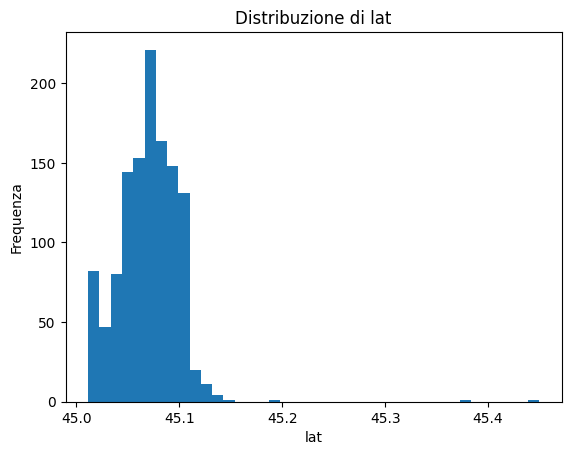


📌 Variabile: lon
Media: 7.67
Dev std: 0.06
Min: 7.61
Max: 9.67


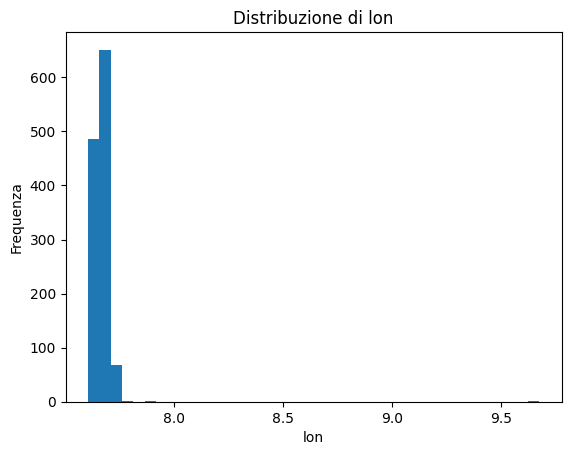


📌 Variabile: dist_metro_m
Media: 2079.98
Dev std: 4964.59
Min: 26.50
Max: 156574.20


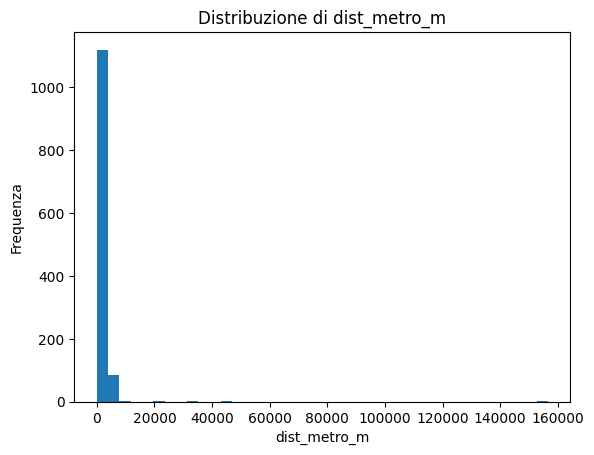


📌 Variabile: minuti_metro
Media: 26.00
Dev std: 62.06
Min: 0.30
Max: 1957.20


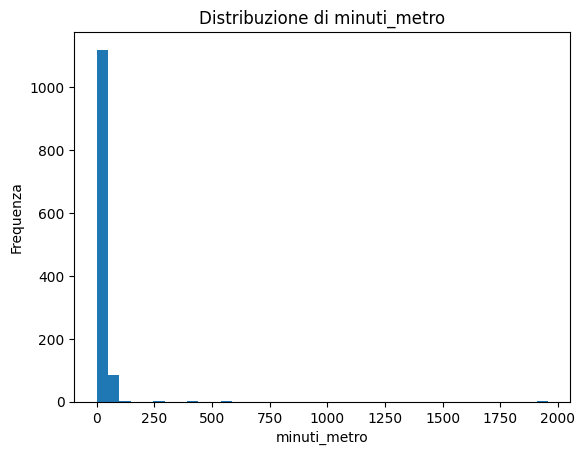


📌 Variabile: dist_tram_m
Media: 734.93
Dev std: 4672.44
Min: 9.70
Max: 152399.00


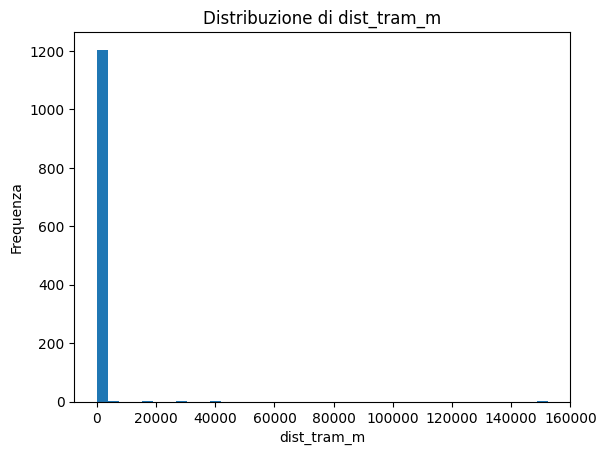


📌 Variabile: minuti_tram
Media: 9.19
Dev std: 58.41
Min: 0.10
Max: 1905.00


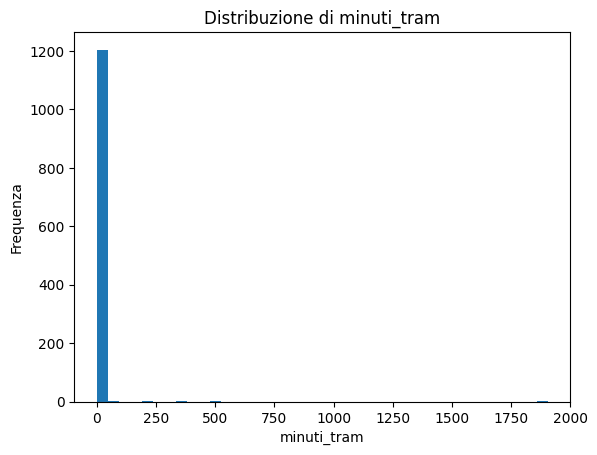


📌 Variabile: dist_bus_m
Media: 191.11
Dev std: 2747.83
Min: 1.90
Max: 95624.00


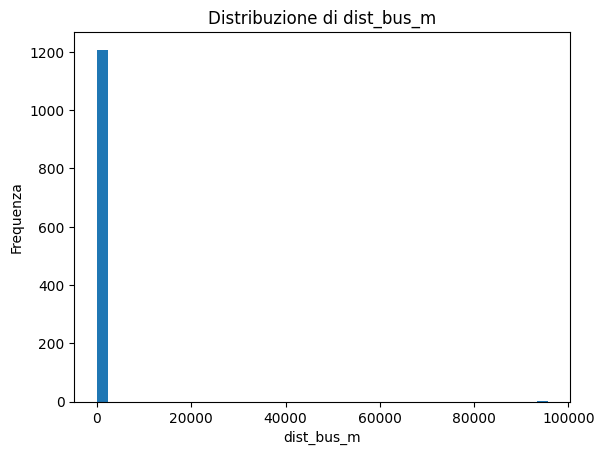


📌 Variabile: minuti_bus
Media: 2.39
Dev std: 34.35
Min: 0.00
Max: 1195.30


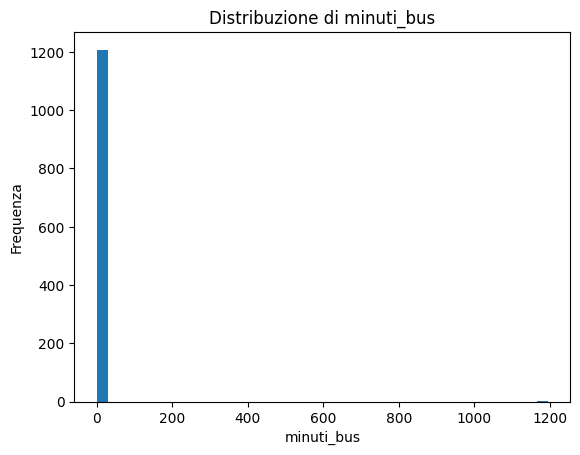


📌 Variabile: distanza_ospedale_m
Media: 1443.97
Dev std: 4675.58
Min: 87.00
Max: 151934.00


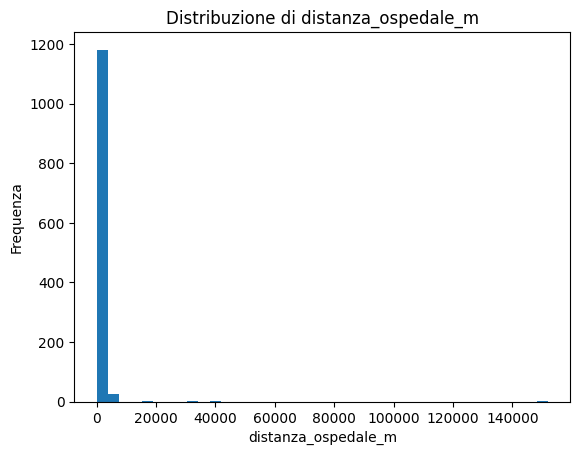


📌 Variabile: tempo_piedi_ospedale_min
Media: 19.25
Dev std: 62.34
Min: 1.20
Max: 2025.80


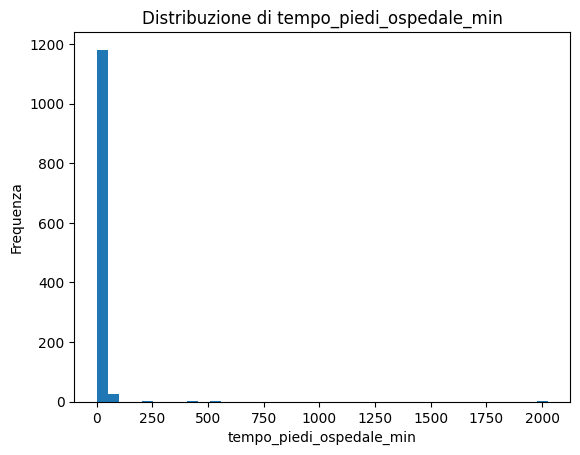


📌 Variabile: distanza_universita_m
Media: 1425.19
Dev std: 4750.61
Min: 45.00
Max: 155388.00


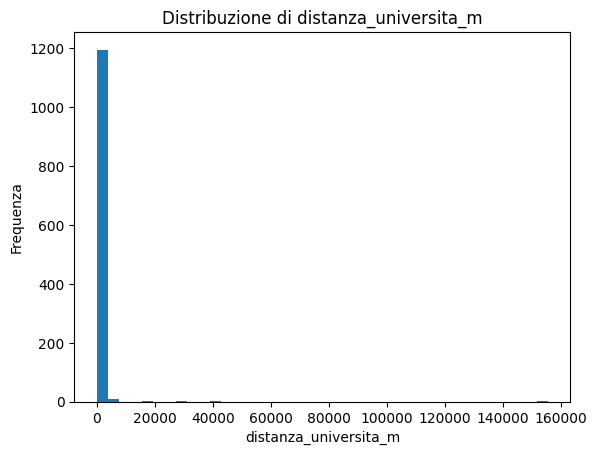


📌 Variabile: tempo_piedi_universita_min
Media: 19.00
Dev std: 63.34
Min: 0.60
Max: 2071.80


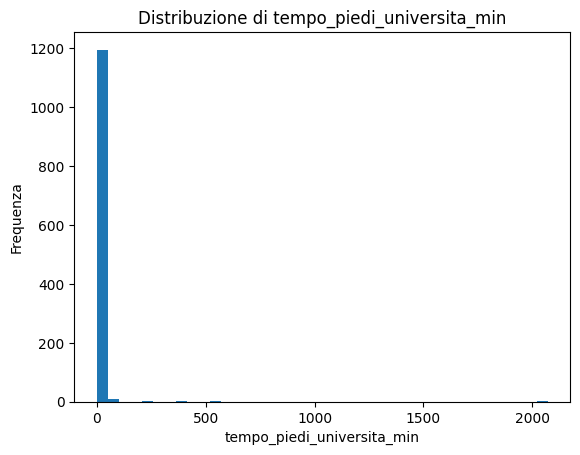


📌 Variabile: distanza_stazione_m
Media: 1727.03
Dev std: 4516.80
Min: 108.00
Max: 149212.00


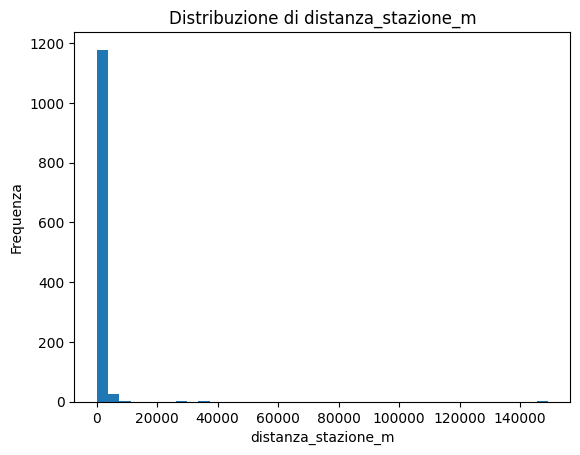


📌 Variabile: stazione_piu_vicino
Media: 456.50
Dev std: 11.83
Min: 419.00
Max: 544.00


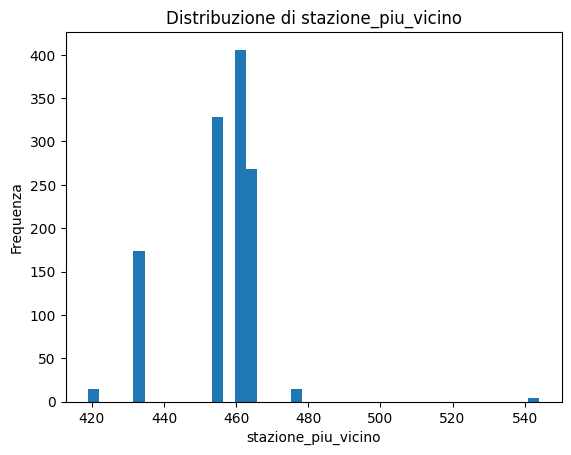


📌 Variabile: tempo_piedi_stazione_min
Media: 23.03
Dev std: 60.22
Min: 1.40
Max: 1989.50


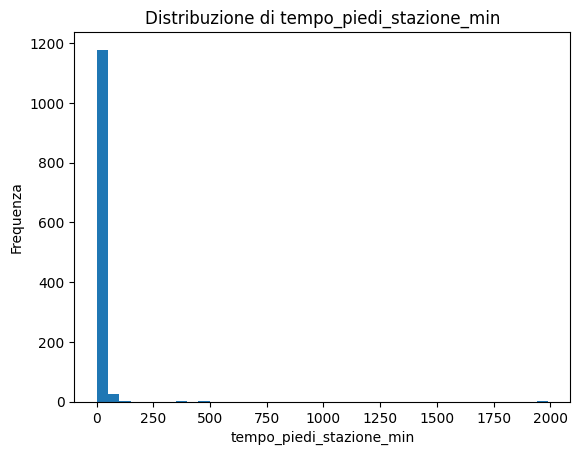


📌 Variabile: distanza_asilo_m
Media: 467.79
Dev std: 4425.54
Min: 8.00
Max: 146033.00


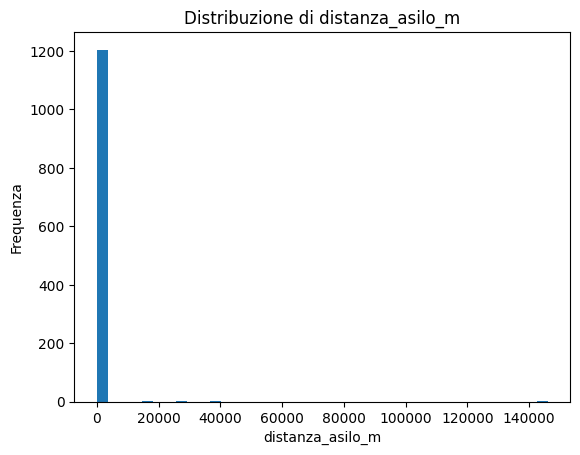


📌 Variabile: tempo_piedi_asilo_min
Media: 6.24
Dev std: 59.01
Min: 0.10
Max: 1947.10


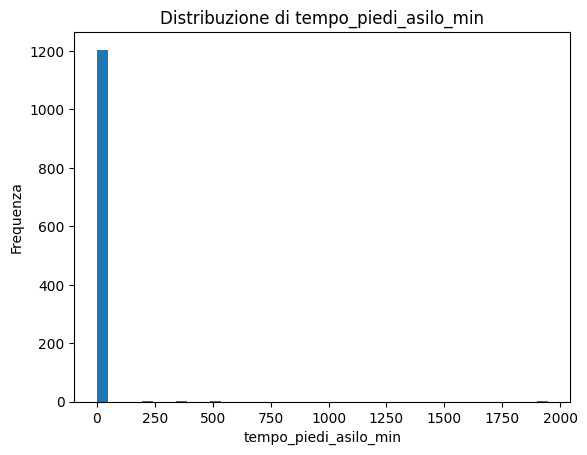


📌 Variabile: distanza_scuola_elementare_m
Media: 511.15
Dev std: 4585.42
Min: 6.00
Max: 151931.00


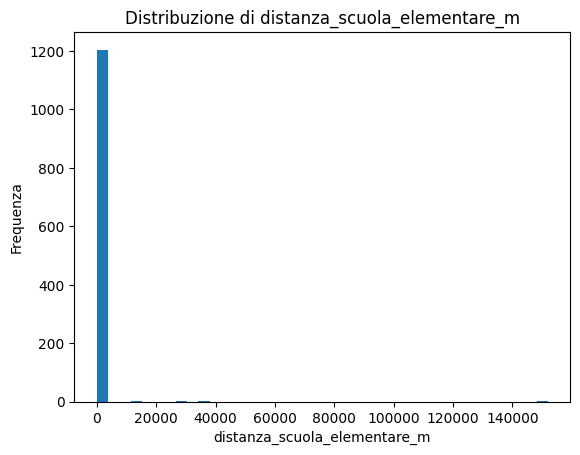


📌 Variabile: tempo_piedi_scuola_elementare_min
Media: 6.81
Dev std: 61.14
Min: 0.10
Max: 2025.70


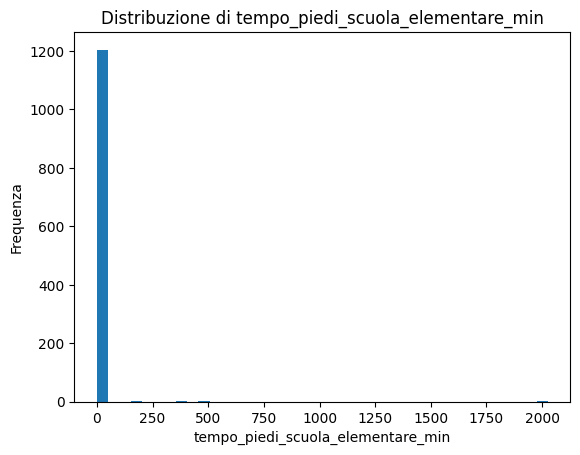


📌 Variabile: distanza_scuola_media_m
Media: 673.47
Dev std: 4627.19
Min: 21.00
Max: 153348.00


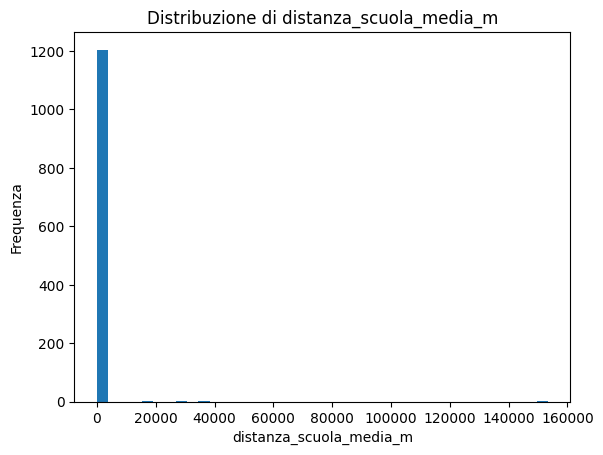


📌 Variabile: tempo_piedi_scuola_media_min
Media: 8.98
Dev std: 61.70
Min: 0.30
Max: 2044.60


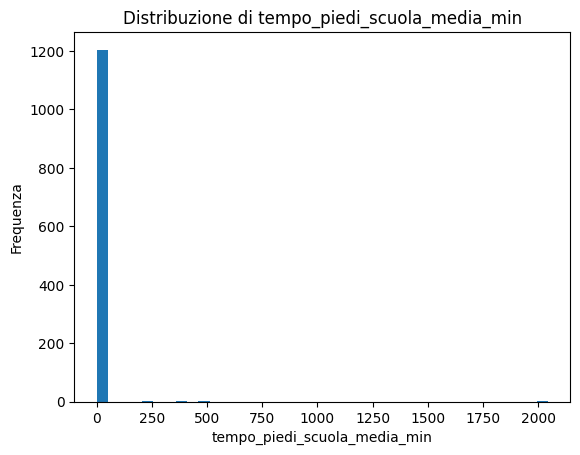


📌 Variabile: distanza_scuola_superiore_m
Media: 898.51
Dev std: 4665.74
Min: 10.00
Max: 154016.00


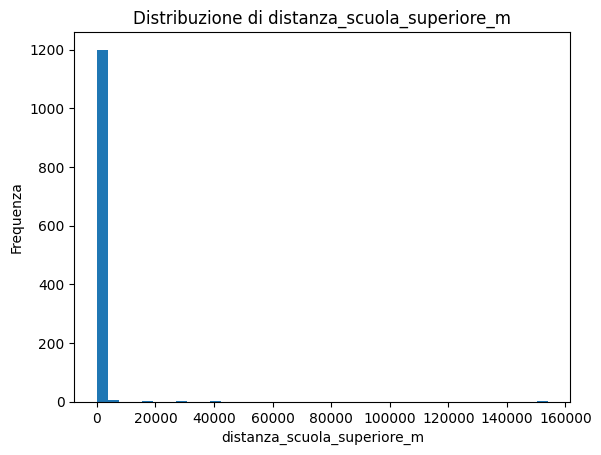


📌 Variabile: tempo_piedi_scuola_superiore_min
Media: 11.98
Dev std: 62.21
Min: 0.10
Max: 2053.50


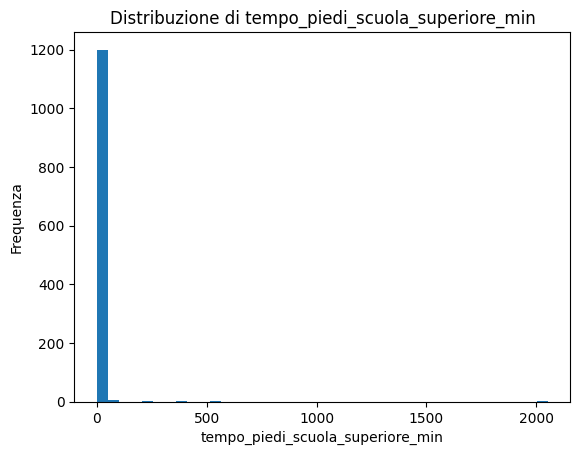


📌 Variabile: numero_locali
Media: 3.12
Dev std: 1.10
Min: 1.00
Max: 5.00


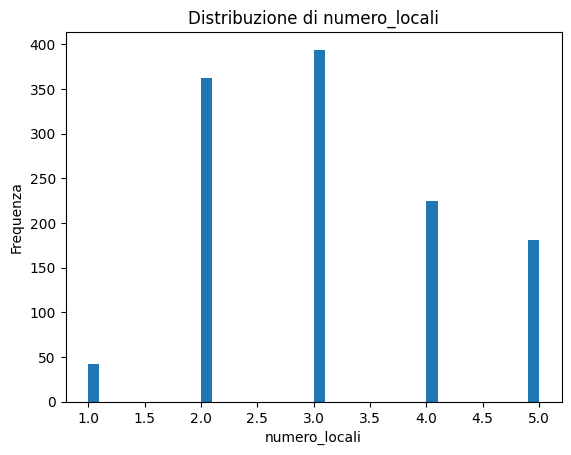


📌 Variabile: size_m2
Media: 90.85
Dev std: 46.68
Min: 1.00
Max: 477.00


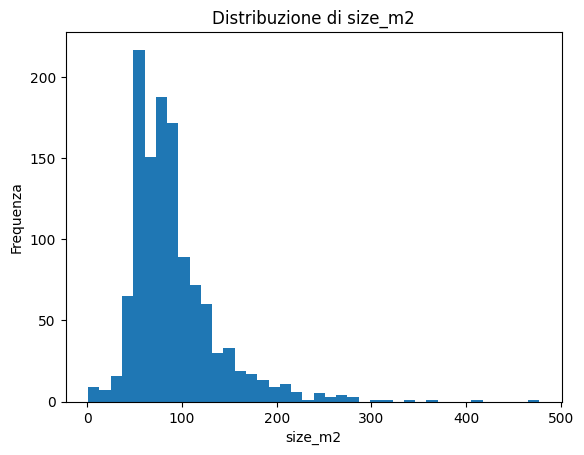


📌 Variabile: Bathrooms
Media: 1.33
Dev std: 0.60
Min: 1.00
Max: 7.00


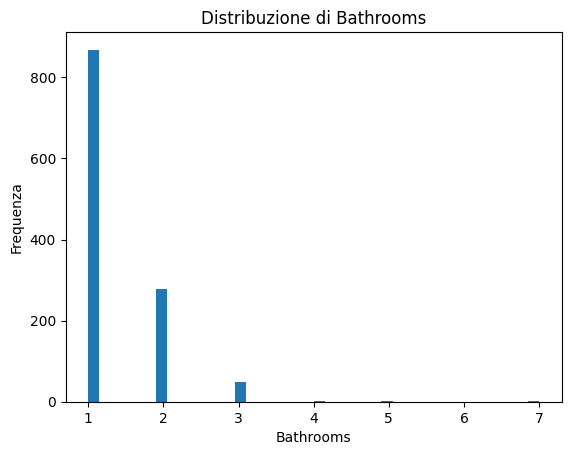


📌 Variabile: floor
Media: 2.72
Dev std: 2.16
Min: 0.00
Max: 11.00


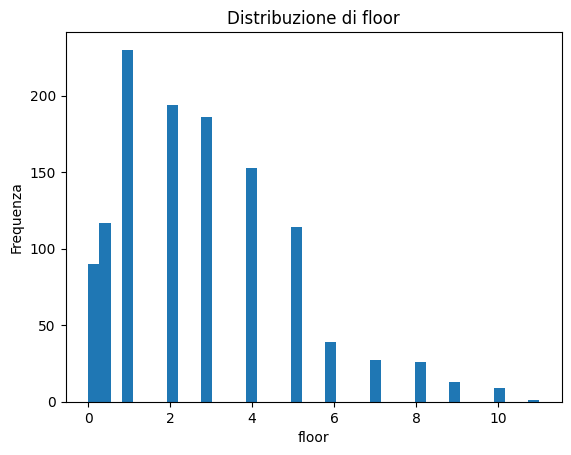


📌 Variabile: price
Media: 219564.97
Dev std: 199090.05
Min: 18000.00
Max: 1890000.00


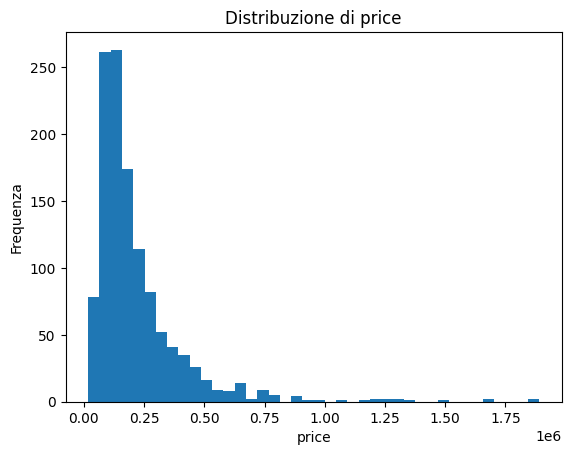


📌 Variabile: Balcony
Media: 1.00
Dev std: 0.00
Min: 1.00
Max: 1.00


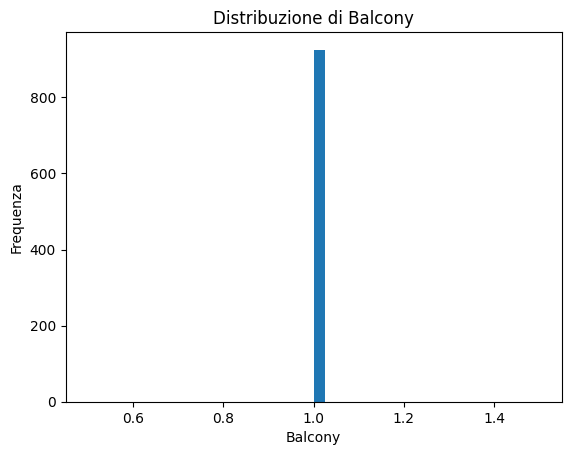


📌 Variabile: coefficient
Media: 99.42
Dev std: 6.13
Min: 25.00
Max: 100.00


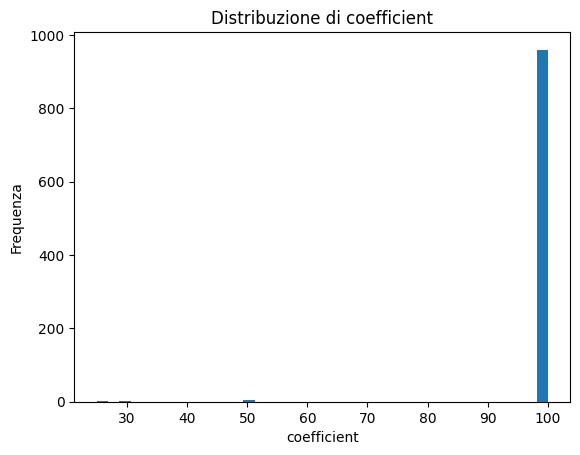


📌 Variabile: elevator_final
Media: 0.72
Dev std: 0.45
Min: 0.00
Max: 1.00


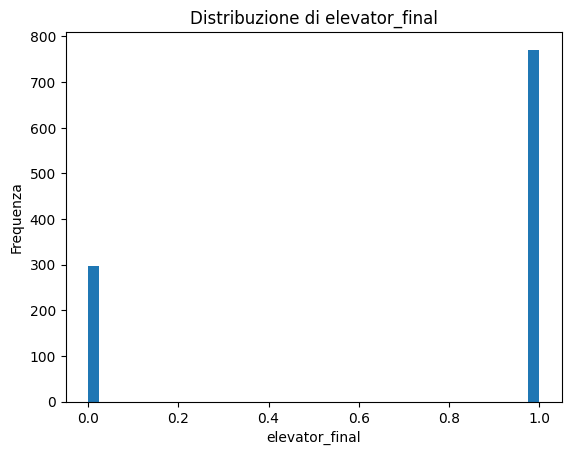

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_dataset(df):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    summary = []

    for col in numeric_cols:
        print("\n" + "="*60)
        print(f"📌 Variabile: {col}")

        mean = df[col].mean()
        std = df[col].std()
        min_v = df[col].min()
        max_v = df[col].max()

        print(f"Media: {mean:.2f}")
        print(f"Dev std: {std:.2f}")
        print(f"Min: {min_v:.2f}")
        print(f"Max: {max_v:.2f}")

        summary.append({
            "feature": col,
            "mean": mean,
            "std": std,
            "min": min_v,
            "max": max_v
        })

        # Histogram
        plt.figure()
        plt.hist(df[col].dropna(), bins=40)
        plt.title(f"Distribuzione di {col}")
        plt.xlabel(col)
        plt.ylabel("Frequenza")
        plt.show()

    return pd.DataFrame(summary)


# USO:
df = pd.read_csv("data/TABLEAU/file_pronto_per_TABLEAU.csv", sep=';', decimal=',')
summary_df = analyze_dataset(df)

## Data Cleaning Adjustments

From the previous results, several issues emerged. Due to errors in latitude and longitude, the computed distances and travel times to key locations were, in some cases, highly inaccurate.

To address this, we remove geographical outliers based on latitude and longitude values, ensuring that only observations within a realistic spatial range are retained.

In addition, we manually identified and removed a specific outlier: four duplicated entries referring to the same property in Pozzo Strada. These records contained incorrect latitude and longitude values, likely caused by an issue in parsing the street name.

Totale righe: 1209
Outlier rimossi: 4
Righe pulite: 1205
Dataset pulito salvato


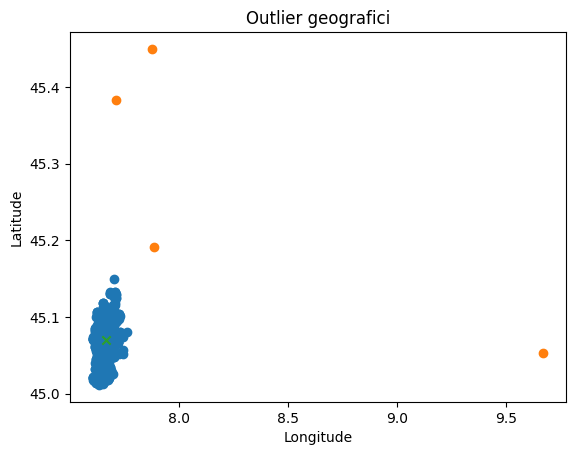

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# LOAD
# -------------------------
df = pd.read_csv("data/TABLEAU/file_pronto_per_TABLEAU.csv", sep=';', decimal=',')

# -------------------------
# MEDIA E STD
# -------------------------
lat_mean = df["lat"].mean()
lon_mean = df["lon"].mean()

lat_std = df["lat"].std()
lon_std = df["lon"].std()

# -------------------------
# DISTANZA NORMALIZZATA DAL CENTRO
# -------------------------
df["z_lat"] = (df["lat"] - lat_mean) / lat_std
df["z_lon"] = (df["lon"] - lon_mean) / lon_std

# distanza euclidea normalizzata
df["distance_from_center"] = np.sqrt(df["z_lat"]**2 + df["z_lon"]**2)

# -------------------------
# DEFINIZIONE OUTLIER
# -------------------------
threshold = 3  # puoi provare 2.5 / 3 / 4

outliers = df[df["distance_from_center"] > threshold]
clean_df = df[df["distance_from_center"] <= threshold]

print("Totale righe:", len(df))
print("Outlier rimossi:", len(outliers))
print("Righe pulite:", len(clean_df))

# save ---------------------

# rimuovi colonne temporanee
clean_df = clean_df.drop(columns=["z_lat", "z_lon", "distance_from_center"])

# rimuoviamo un outlier che ho individuato a mano (4 righe dello stesso immobile in Pozzo strada di cui sono state dedotte male le coordinate lat e lon
# a causa di un problema nel nome della via)
clean_df = clean_df[~(
    (clean_df["lon"] == 7.7557576) &
    (clean_df["lat"] == 45.1039293)
)]


# salva dataset pulito
clean_df.to_csv("data/TABLEAU/file_pronto_per_TABLEAU_V2(no_outliers).csv", sep=';', decimal=',', index=False)

print("Dataset pulito salvato")

# -------------------------
# PLOT
# -------------------------
plt.figure()

# punti normali
plt.scatter(clean_df["lon"], clean_df["lat"])

# outlier evidenziati
plt.scatter(outliers["lon"], outliers["lat"])

# centro
plt.scatter(lon_mean, lat_mean, marker="x")

plt.title("Outlier geografici")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Re-check After Data Cleaning

After applying the initial data cleaning steps, we re-run the same descriptive statistics code to verify the effectiveness of the corrections.

This allows us to compare the distribution of each feature before and after outlier removal, ensuring that extreme and unrealistic values have been reduced or eliminated.

By repeating the same analysis pipeline, we can confirm whether the dataset now shows more consistent ranges, lower variance, and more realistic maximum values, improving overall data quality for model training.


📌 Variabile: lat
Media: 45.07
Dev std: 0.03
Min: 45.01
Max: 45.15


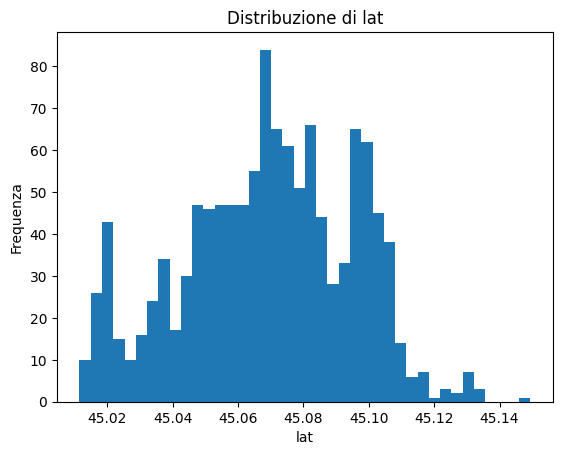


📌 Variabile: lon
Media: 7.67
Dev std: 0.03
Min: 7.61
Max: 7.77


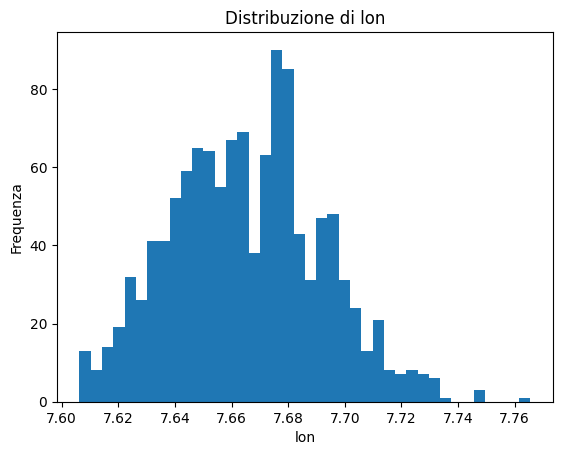


📌 Variabile: dist_metro_m
Media: 1849.46
Dev std: 1424.06
Min: 26.50
Max: 8697.10


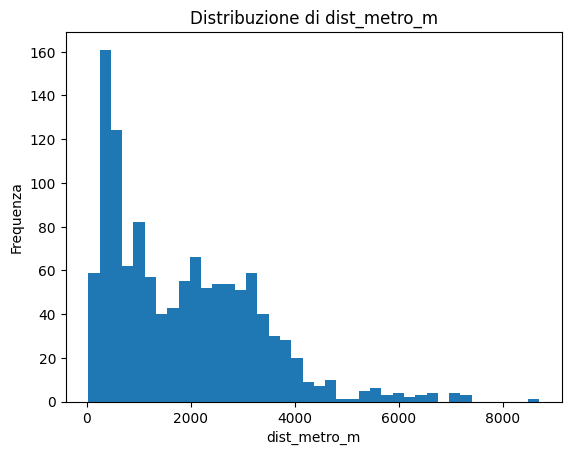


📌 Variabile: minuti_metro
Media: 23.12
Dev std: 17.80
Min: 0.30
Max: 108.70


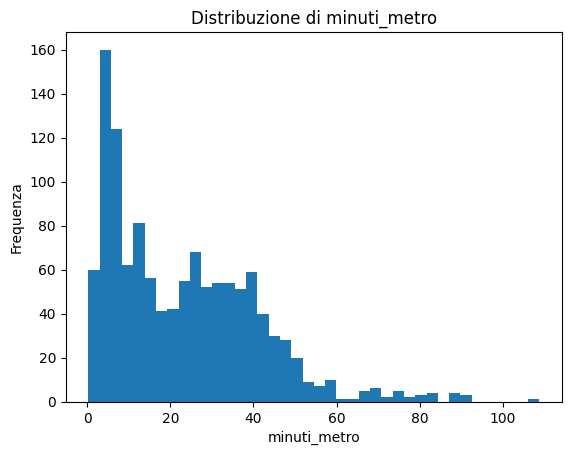


📌 Variabile: dist_tram_m
Media: 525.87
Dev std: 638.03
Min: 9.70
Max: 5413.90


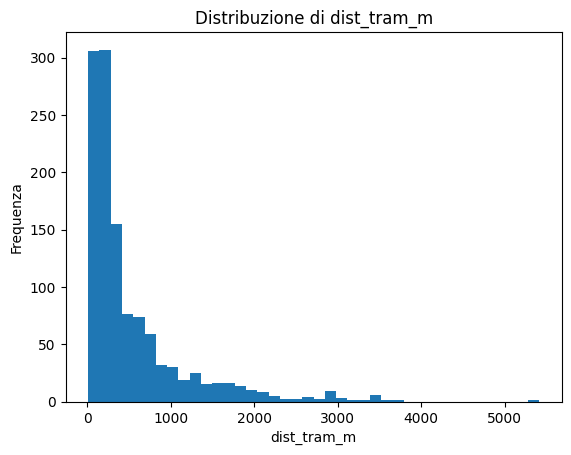


📌 Variabile: minuti_tram
Media: 6.57
Dev std: 7.98
Min: 0.10
Max: 67.70


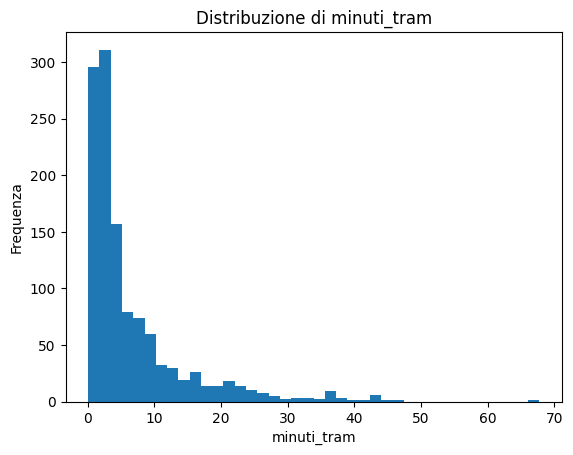


📌 Variabile: dist_bus_m
Media: 112.23
Dev std: 71.46
Min: 1.90
Max: 766.30


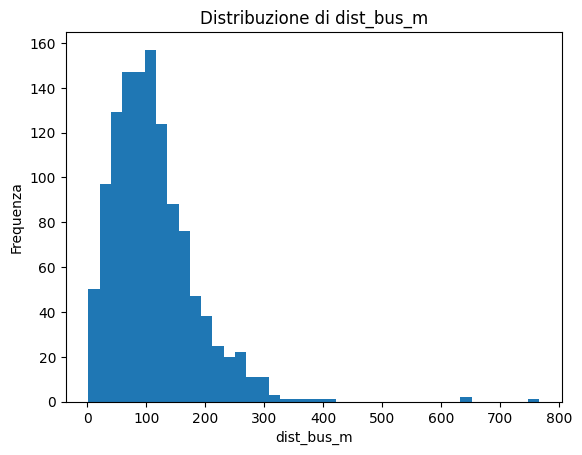


📌 Variabile: minuti_bus
Media: 1.40
Dev std: 0.90
Min: 0.00
Max: 9.60


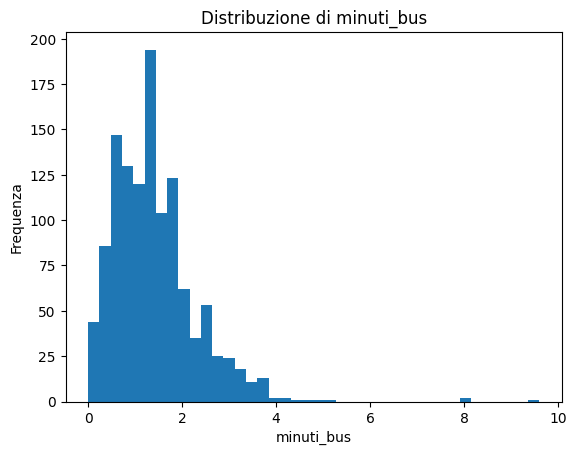


📌 Variabile: distanza_ospedale_m
Media: 1235.84
Dev std: 857.71
Min: 87.00
Max: 5807.00


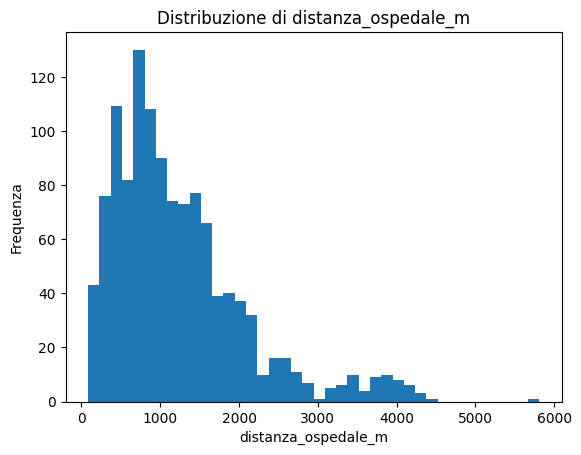


📌 Variabile: tempo_piedi_ospedale_min
Media: 16.48
Dev std: 11.43
Min: 1.20
Max: 77.40


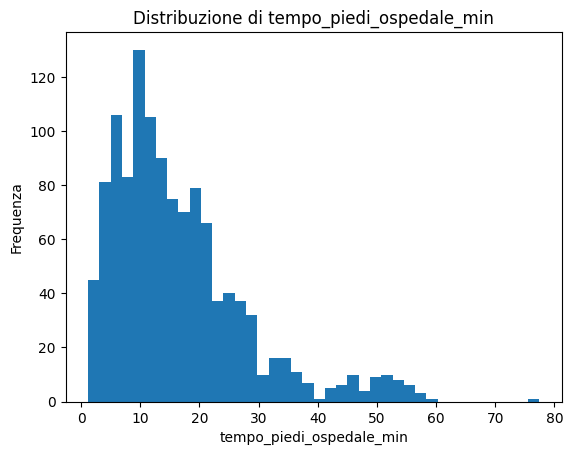


📌 Variabile: distanza_universita_m
Media: 1212.30
Dev std: 791.12
Min: 45.00
Max: 5244.00


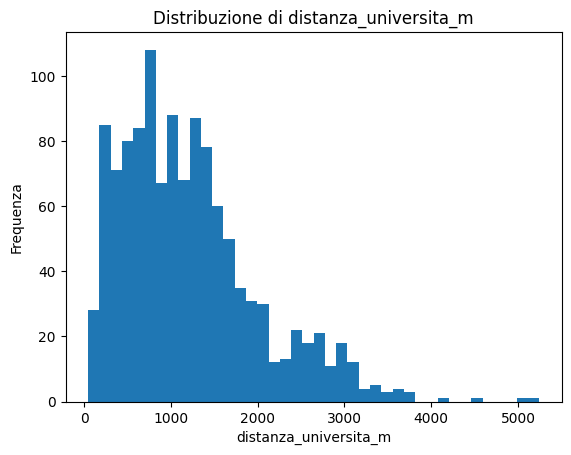


📌 Variabile: tempo_piedi_universita_min
Media: 16.16
Dev std: 10.55
Min: 0.60
Max: 69.90


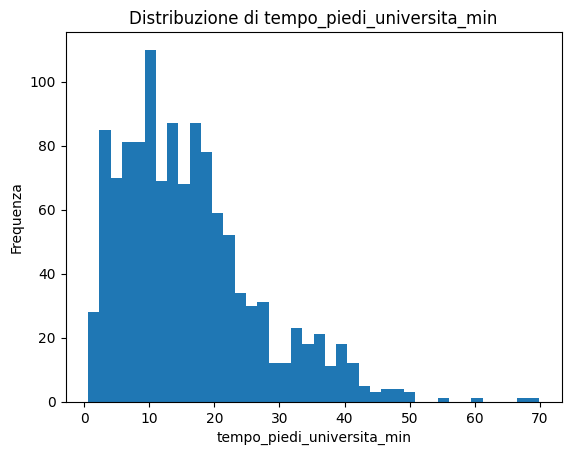


📌 Variabile: distanza_stazione_m
Media: 1537.90
Dev std: 887.14
Min: 108.00
Max: 6196.00


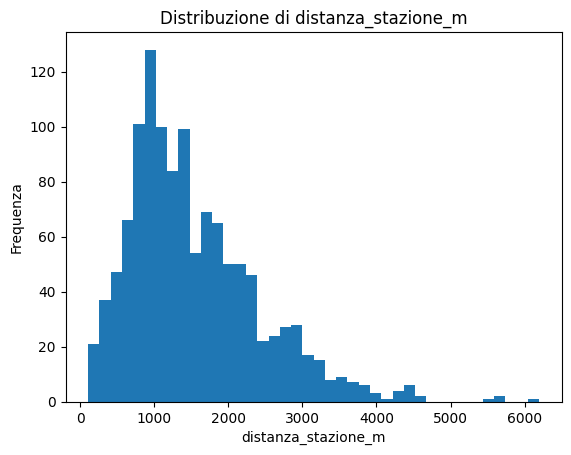


📌 Variabile: stazione_piu_vicino
Media: 456.55
Dev std: 11.71
Min: 422.00
Max: 544.00


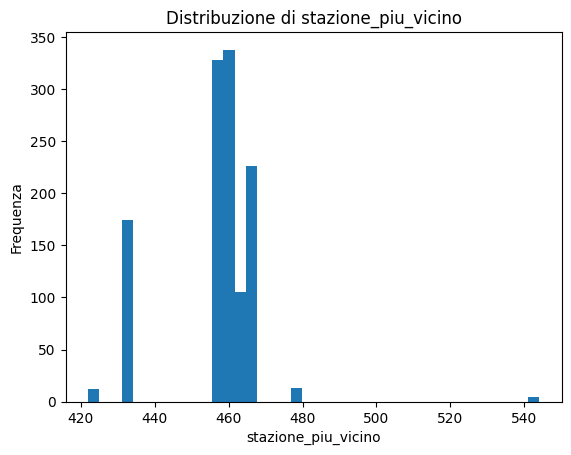


📌 Variabile: tempo_piedi_stazione_min
Media: 20.50
Dev std: 11.83
Min: 1.40
Max: 82.60


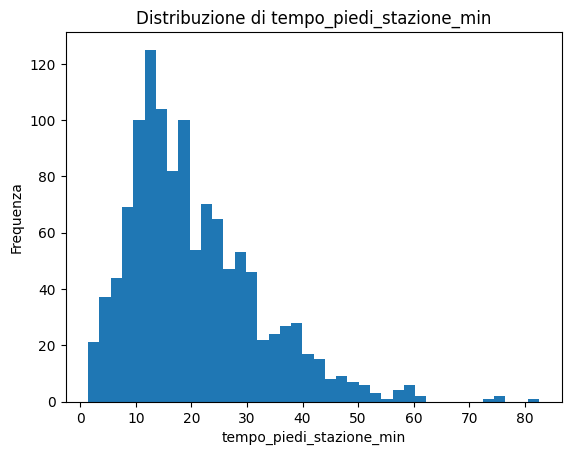


📌 Variabile: distanza_asilo_m
Media: 278.10
Dev std: 209.37
Min: 8.00
Max: 2155.00


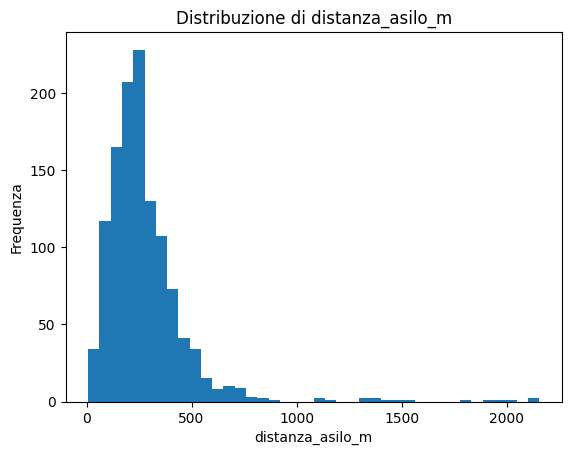


📌 Variabile: tempo_piedi_asilo_min
Media: 3.71
Dev std: 2.79
Min: 0.10
Max: 28.70


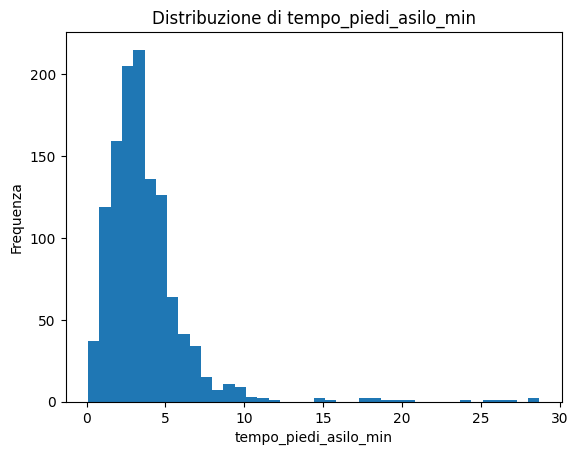


📌 Variabile: distanza_scuola_elementare_m
Media: 316.56
Dev std: 216.55
Min: 6.00
Max: 2580.00


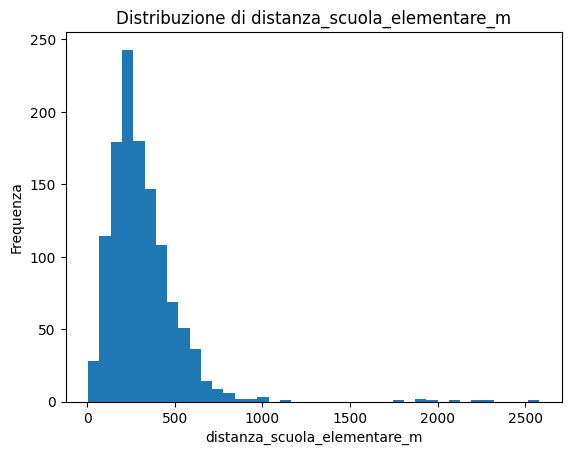


📌 Variabile: tempo_piedi_scuola_elementare_min
Media: 4.22
Dev std: 2.89
Min: 0.10
Max: 34.40


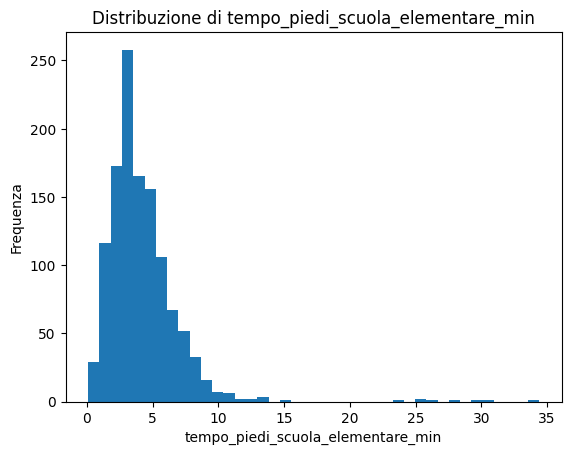


📌 Variabile: distanza_scuola_media_m
Media: 472.90
Dev std: 339.77
Min: 21.00
Max: 3297.00


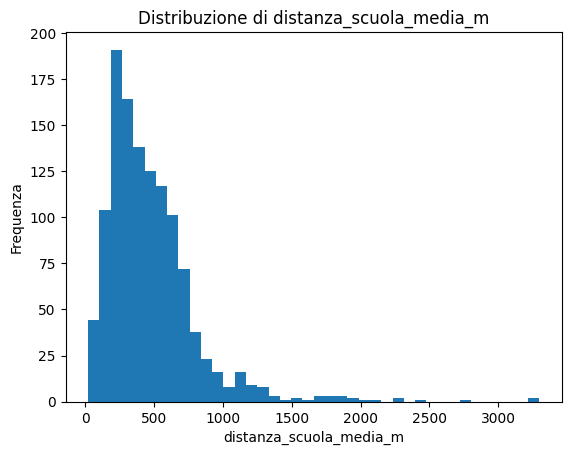


📌 Variabile: tempo_piedi_scuola_media_min
Media: 6.31
Dev std: 4.53
Min: 0.30
Max: 44.00


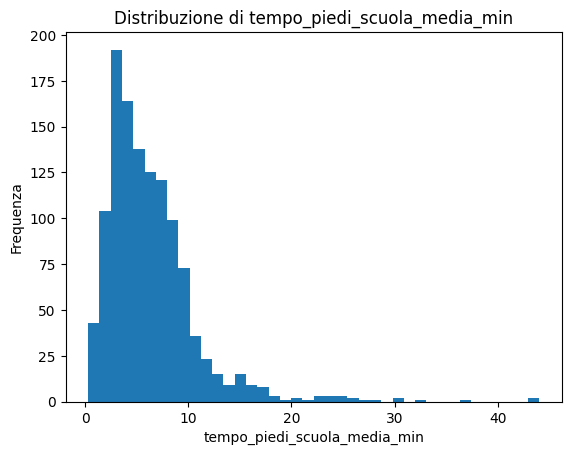


📌 Variabile: distanza_scuola_superiore_m
Media: 688.92
Dev std: 443.06
Min: 10.00
Max: 3833.00


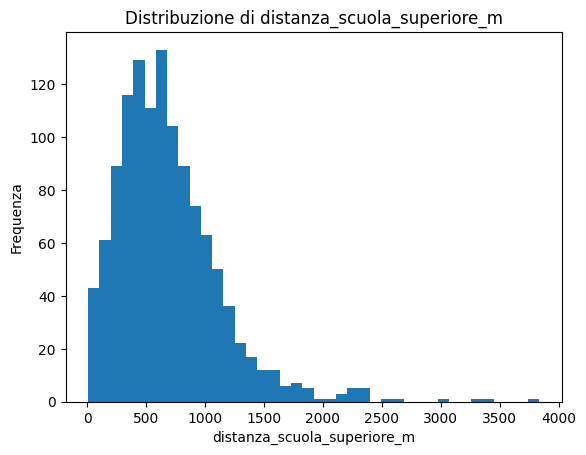


📌 Variabile: tempo_piedi_scuola_superiore_min
Media: 9.19
Dev std: 5.91
Min: 0.10
Max: 51.10


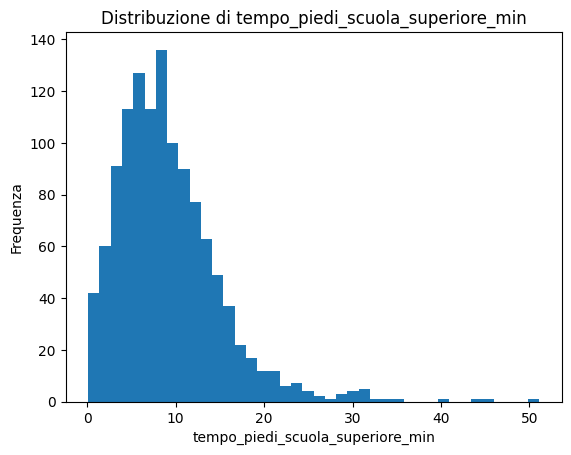


📌 Variabile: numero_locali
Media: 3.12
Dev std: 1.10
Min: 1.00
Max: 5.00


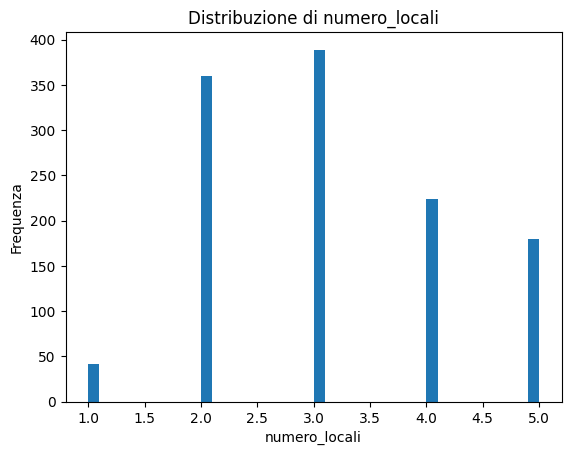


📌 Variabile: size_m2
Media: 90.87
Dev std: 46.77
Min: 1.00
Max: 477.00


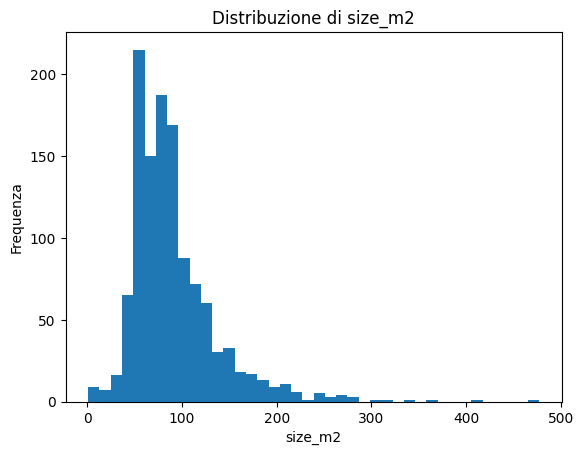


📌 Variabile: Bathrooms
Media: 1.33
Dev std: 0.60
Min: 1.00
Max: 7.00


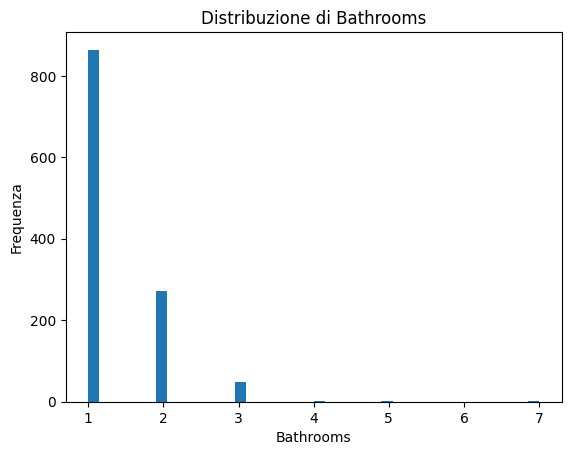


📌 Variabile: floor
Media: 2.72
Dev std: 2.15
Min: 0.00
Max: 10.00


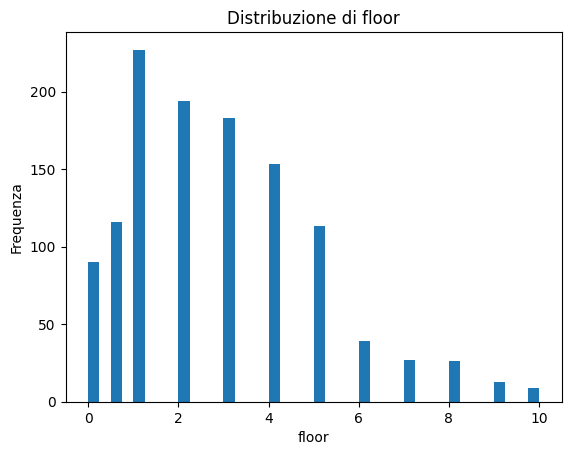


📌 Variabile: price
Media: 219206.71
Dev std: 199644.94
Min: 18000.00
Max: 1890000.00


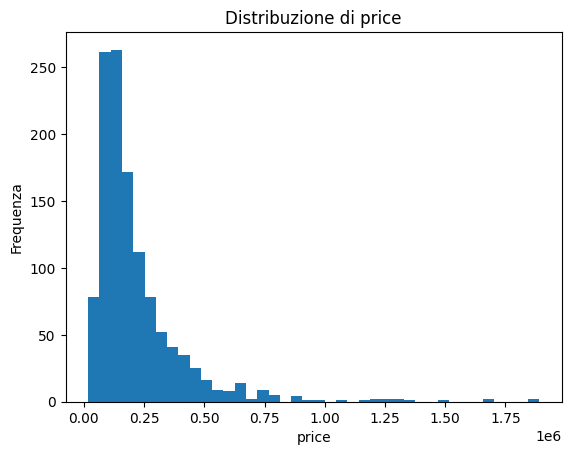


📌 Variabile: Balcony
Media: 1.00
Dev std: 0.00
Min: 1.00
Max: 1.00


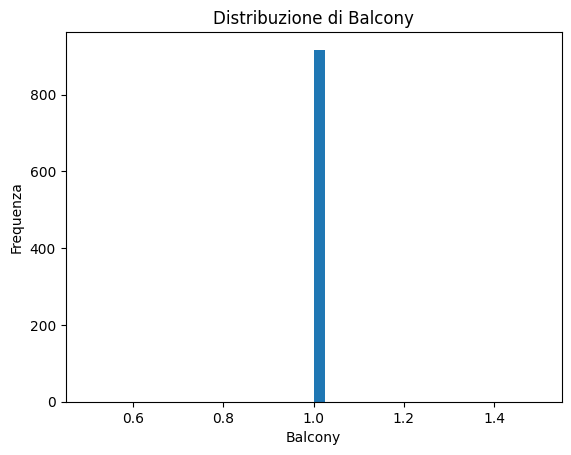


📌 Variabile: coefficient
Media: 99.41
Dev std: 6.15
Min: 25.00
Max: 100.00


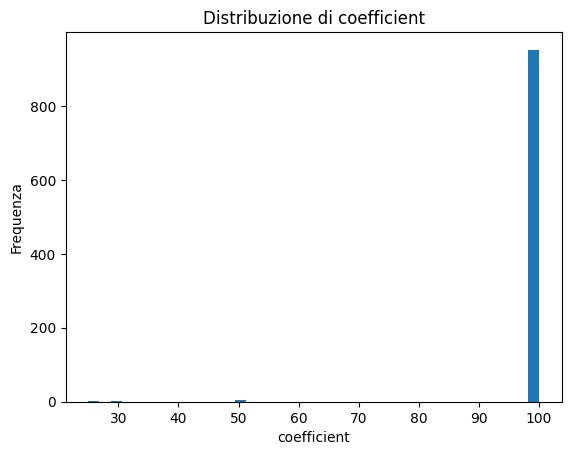


📌 Variabile: elevator_final
Media: 0.72
Dev std: 0.45
Min: 0.00
Max: 1.00


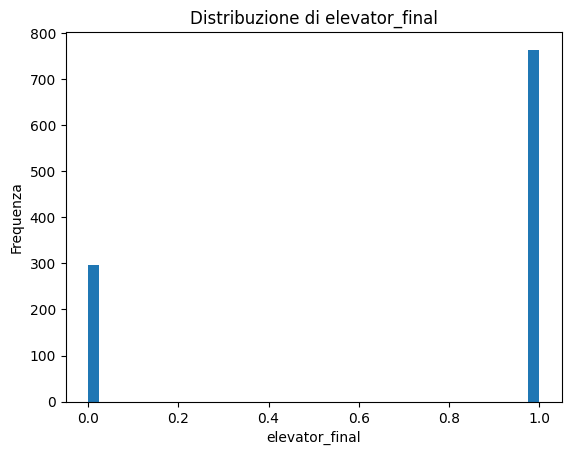

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_dataset(df):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    summary = []

    for col in numeric_cols:
        print("\n" + "="*60)
        print(f"📌 Variabile: {col}")

        mean = df[col].mean()
        std = df[col].std()
        min_v = df[col].min()
        max_v = df[col].max()

        print(f"Media: {mean:.2f}")
        print(f"Dev std: {std:.2f}")
        print(f"Min: {min_v:.2f}")
        print(f"Max: {max_v:.2f}")

        summary.append({
            "feature": col,
            "mean": mean,
            "std": std,
            "min": min_v,
            "max": max_v
        })

        # Histogram
        plt.figure()
        plt.hist(df[col].dropna(), bins=40)
        plt.title(f"Distribuzione di {col}")
        plt.xlabel(col)
        plt.ylabel("Frequenza")
        plt.show()

    return pd.DataFrame(summary)


# USO:
df = pd.read_csv("data/TABLEAU/file_pronto_per_TABLEAU_V2(no_outliers).csv", sep=';', decimal=',')
summary_df = analyze_dataset(df)

# 26. Analysis of Duplicate Records

In this section, we analyze the presence of duplicate records within the dataset.

To properly understand the structure of the data, we investigate potential duplicates by considering a combination of key identifiers such as geographic coordinates (lat, lon).

The goal of this analysis is not to immediately remove duplicates, but to understand how frequently the same property appears and how it evolves over time in the dataset.

In [13]:
import pandas as pd

df = pd.read_csv("data/TABLEAU/file_pronto_per_TABLEAU_V2(no_outliers).csv", sep=';', decimal=',')

# -------------------------
# DUPLICATI SU LAT + LON
# -------------------------
duplicates = df[df.duplicated(subset=["lat", "lon"], keep=False)]

print("Numero righe duplicate:", len(duplicates))

# ordiniamo per vedere meglio
duplicates_sorted = duplicates.sort_values(by=["lat", "lon"])

duplicates_sorted.head(50)

Numero righe duplicate: 217


,energy_class,tipo_immobile,via,civico,quartiere,citta,lat,lon,dist_metro_m,minuti_metro,...,size_m2,Bathrooms,floor,price,Balcony,coefficient,elevator_final,esposizione,infissi_vetro,infissi_materiale
904,A,Appartamento,Strada del Fioccardo,206,Cavoretto,Torino,45.020079,7.679992,1336.5,16.7,...,224.0,2.0,3.0,540000.0,1.0,100.0,1.0,doppia,vetro,legno
1110,E,Quadrilocale,Strada del Fioccardo,206,Cavoretto,Torino,45.020079,7.679992,1336.5,16.7,...,120.0,2.0,1.0,389000.0,1.0,100.0,1.0,NaN,doppio vetro,legno
925,A,Appartamento,via plava,115,Mirafiori Sud - Strada del Drosso,Torino,45.020174,7.615170,3641.0,45.5,...,100.0,1.0,8.0,119000.0,1.0,NaN,1.0,NaN,NaN,NaN
965,F,Appartamento,via Plava,115,Mirafiori Sud - Strada del Drosso,Torino,45.020174,7.615170,3641.0,45.5,...,113.0,1.0,0.0,119000.0,1.0,100.0,1.0,doppia,doppio vetro,legno
146,E,Villa bifamiliare,Strada dai Ronchi ai Cunioli Alti,13,Cavoretto,Torino,45.026861,7.696710,2465.1,30.8,...,245.0,3.0,0.5,670000.0,NaN,100.0,NaN,esterna,vetro,legno
292,E,Villa unifamiliare,Strada dai Ronchi ai Cunioli Alti,13,Cavoretto,Torino,45.026861,7.696710,2465.1,30.8,...,245.0,3.0,0.5,670000.0,NaN,100.0,NaN,esterna,vetro,legno
817,C,Trilocale,corso Eusebio Giambone,63,Lingotto,Torino,45.030839,7.653567,1082.8,13.5,...,125.0,2.0,3.0,389000.0,1.0,100.0,1.0,doppia,doppio vetro,pvc
1161,F,Quadrilocale,corso Eusebio Giambone,63,Lingotto,Torino,45.030839,7.653567,1082.8,13.5,...,125.0,2.0,3.0,229000.0,1.0,100.0,NaN,doppia,vetro,legno
182,F,Appartamento,via Garessio,24/6,Nizza Millefonti,Torino,45.031147,7.669995,270.1,3.4,...,152.0,2.0,0.5,270000.0,1.0,100.0,1.0,doppia,vetro,legno
670,E,Appartamento,via Garessio,24/10,Nizza Millefonti,Torino,45.031147,7.669995,270.1,3.4,...,170.0,3.0,5.0,435000.0,1.0,NaN,1.0,NaN,NaN,NaN


## Duplicate Removal Using Latest Update

After analyzing duplicate records, we found 217 duplicates. We proceed with data cleaning by keeping only the most recent observation for each property.

Since the same property can appear multiple times due to price updates or listing revisions, we use the `data_aggiornamento` column to identify the most recent entry.

For each unique property (defined by latitude, longitude), we sort the dataset by update date and retain only the latest record.<

In [15]:
import pandas as pd

# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv("data/TABLEAU/file_pronto_per_TABLEAU_V2(no_outliers).csv", sep=';', decimal=',')

# -------------------------
# CONVERT DATE
# -------------------------
df["data_aggiornamento"] = pd.to_datetime(df["data_aggiornamento"], errors="coerce")

# -------------------------
# DEFINE IMMOBILE IDENTIFIER
# (puoi modificarlo se vuoi più precisione)
# -------------------------
immobile_keys = [
    "lat",
    "lon",
]

# -------------------------
# SORT BY LATEST UPDATE
# -------------------------
df = df.sort_values(by=immobile_keys + ["data_aggiornamento"])

# -------------------------
# DROP DUPLICATES KEEP LAST UPDATE
# -------------------------
df_clean = df.drop_duplicates(
    subset=immobile_keys,
    keep="last"
)

df_clean.to_csv("data/TABLEAU/file_pronto_per_TABLEAU_V3(no_duplicates).csv", sep=';', decimal=',', index=False)

# -------------------------
# RESULT
# -------------------------
print("Original rows:", len(df))
print("After deduplication:", len(df_clean))
print("Removed:", len(df) - len(df_clean))

Original rows: 1200
After deduplication: 1068
Removed: 132


# 27. Luxury Feature Engineering

We will create a new feature called **`luxury_score`** from the text field `Product_3_Energy_Class`, which contains the property description.

The idea is to detect whether the listing contains luxury-related terms such as *“lusso”*, *“signorile”*, *“prestigio”*, or similar expressions.

This feature will help the model better capture high-end properties that are not clearly distinguishable using only numerical variables.

In [17]:
import pandas as pd

# -----------------------------
# 1. LOAD MAIN DATASET
# -----------------------------
df = pd.read_csv(
    "data/TABLEAU/file_pronto_per_TABLEAU_V3(no_duplicates).csv",
    sep=';',
    decimal=','
)

# -----------------------------
# 2. LOAD SECOND DATASET (con descrizioni)
# -----------------------------
df_desc = pd.read_csv(
    "data/file_pulito_V8(cahrateristics).csv",
    sep=';',
    decimal=','
)

# -----------------------------
# 3. MERGE DATASETS
# -----------------------------
# ⚠️ cambia "id" con la tua vera chiave
df = df.merge(
    df_desc[["lat", "lon", "Product_3_Energy_Class"]],
    on=["lat", "lon"],
    how="left"
)

# -----------------------------
# 4. FEATURE ENGINEERING: LUXURY SCORE
# -----------------------------
def luxury_score(text):
    if pd.isna(text):
        return 0

    text = str(text).lower()

    score = 0

    # strong signals
    score += text.count("lusso") * 2
    score += text.count("lussuoso") * 2
    score += text.count("prestigio") * 2
    score += text.count("prestigioso") * 2
    score += text.count("signorile") * 2
    score += text.count("di pregio") * 2
    score += text.count("di rappresentanza") * 2

    # medium signals
    score += text.count("esclusivo") * 1
    score += text.count("esclusività") * 1
    score += text.count("attico") * 1
    score += text.count("villa") * 1
    score += text.count("dimora") * 1

    return min(score, 5)

df["luxury_score"] = df["Product_3_Energy_Class"].apply(luxury_score)

# -----------------------------
# 5. CHECK DISTRIBUTION
# -----------------------------
print(df["luxury_score"].value_counts().sort_index())

# -----------------------------
# 6. DROP ORIGINAL TEXT (opzionale ma consigliato)
# -----------------------------
df = df.drop(columns=["Product_3_Energy_Class"])

# -----------------------------
# 7. SAVE NEW DATASET
# -----------------------------
output_path = "data/TABLEAU/file_TABLEAU_V4(luxury).csv"
df.to_csv(output_path, index=False, sep=';', decimal=',')

print(f"Dataset salvato in: {output_path}")

luxury_score
0    842
1     53
2    171
3     29
4     42
5     63
Name: count, dtype: int64
Dataset salvato in: data/TABLEAU/file_TABLEAU_V4(luxury).csv
